In [149]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# importing libraries
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from google.colab import drive
drive.mount('/content/drive')
# mounting the drive for importing files

from google.colab import files

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [150]:
df = pd.read_csv('/content/drive/MyDrive/dataanalytics/Sample - Superstore.csv')

In [151]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [152]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


- The dataset contains sales transactions with Order Date, Sales, Profit, Quantity, and Discount columns.

- We will convert Order Date to datetime format and extract Year and Month.

- All other columns are properly formatted and ready for analysis.

We proceed with cleaning and preparing the data for sales analysis.

In [153]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

Data preprocessing for Superstore dataset:
- Order Date has been converted to datetime format.
- Year and Month have been extracted for trend analysis.
- All numeric columns (Sales, Profit, Quantity, Discount) are ready for analysis.

In [154]:
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')

Missing values in numeric columns (Sales, Profit, Quantity, Discount) are filled with column means to preserve distribution. This approach is appropriate for continuous data used in statistical analysis.

In [155]:
# Fill missing values in numeric columns with the mean
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())
df['Profit'] = df['Profit'].fillna(df['Profit'].mean())

df['Quantity'] = df['Quantity'].fillna(df['Quantity'].mean())
df['Discount'] = df['Discount'].fillna(df['Discount'].mean())

In [156]:
df.isnull().sum()
# now we do not have any null values in our dataset

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [157]:
df.duplicated().sum()
# this shows that there are no duplicate values

np.int64(0)

In [158]:
df.shape

(9994, 23)

In [159]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month,Year
0,1,CA-2016-152156,2016-11-08,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016
1,2,CA-2016-152156,2016-11-08,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015


In [160]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [161]:
df.tail(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month,Year
9989,9990,CA-2014-110422,2014-01-21,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028,1,2014
9990,9991,CA-2017-121258,2017-02-26,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332,2,2017
9991,9992,CA-2017-121258,2017-02-26,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932,2,2017
9992,9993,CA-2017-121258,2017-02-26,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200,2,2017
9993,9994,CA-2017-119914,2017-05-04,05-09-2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480,5,2017


In [162]:
df.describe()

,Row ID,Order Date,Postal Code,Sales,Quantity,Discount,Profit,Month,Year
count,9994.000000,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,55190.379428,229.858001,3.789574,0.156203,28.656896,7.809686,2015.722233
min,1.000000,2014-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,1.000000,2014.000000
25%,2499.250000,2015-05-23 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,5.000000,2015.000000
50%,4997.500000,2016-06-26 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,9.000000,2016.000000
75%,7495.750000,2017-05-14 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,11.000000,2017.000000
max,9994.000000,2017-12-30 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,12.000000,2017.000000
std,2885.163629,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,3.284654,1.123555


## Exploratory Data Analysis (EDA)

From here onwards we start Exploratory Data Analysis. For classification tasks with imbalanced target variables, class imbalance correction using SMOTE will be applied. K-Means clustering is unsupervised, so class imbalance doesn't affect it.

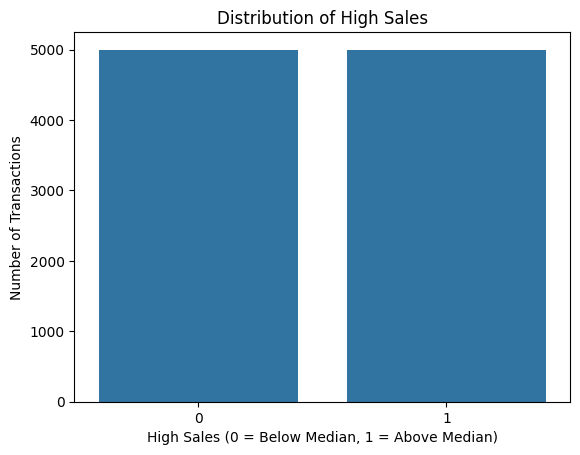

Sales distribution (%):
High_Sales
0    50.0
1    50.0
Name: count, dtype: float64


In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create binary target variable High_Sales based on median
median_sales = df['Sales'].median()
df['High_Sales'] = (df['Sales'] > median_sales).astype(int)

# Count values
sales_counts = df['High_Sales'].value_counts().sort_index()

# Plot the graph
sns.barplot(x=sales_counts.index, y=sales_counts.values)
plt.title('Distribution of High Sales')
plt.xlabel('High Sales (0 = Below Median, 1 = Above Median)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1])
plt.show()

# Print percentage of each class
percentage = (sales_counts / df.shape[0]) * 100
print("Sales distribution (%):")
print(percentage.round(2))

## Target Variable Analysis

- Approximately 50% of transactions have sales above the median (High_Sales = 1).
- Approximately 50% of transactions have sales below or equal to the median (High_Sales = 0).
- The balanced distribution of the High_Sales target variable means the dataset is well-balanced for classification tasks.
- K-Means clustering is unsupervised, so class balance doesn't affect its performance.

In [164]:
df['Region'].value_counts()
# shows the distribution of sales by region

,count
Region,
West,3203
East,2848
Central,2323
South,1620


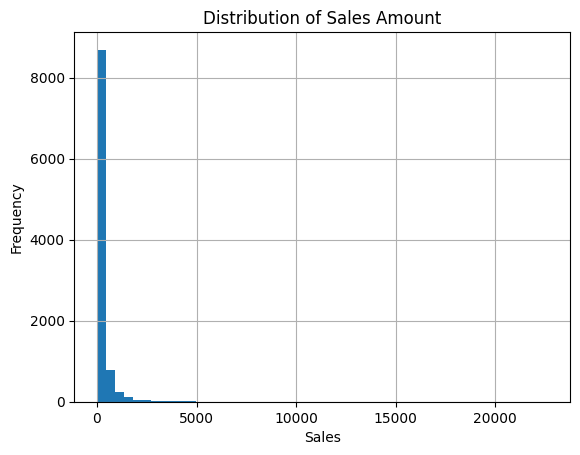

In [165]:
df['Sales'].hist(bins=50)
plt.title('Distribution of Sales Amount')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

In [166]:
df['Category'].value_counts()
# shows the distribution of sales by product category

,count
Category,
Office Supplies,6026
Furniture,2121
Technology,1847


In [167]:
df[['Sales', 'Profit', 'Quantity']].sum()
# shows total sales, profit, and quantity across all transactions

,0
Sales,2.297201e+06
Profit,2.863970e+05
Quantity,3.787300e+04


In [168]:
df[['Discount', 'Quantity', 'Year']].sum()
# shows total discount applied, total quantity sold, and year distribution

,0
Discount,1561.09
Quantity,37873.00
Year,20145128.00


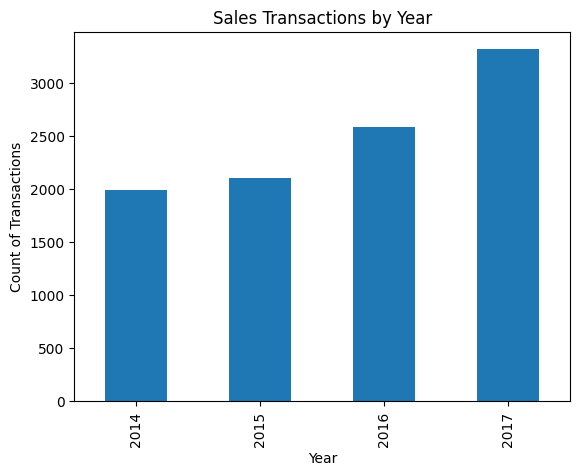

In [169]:
df['Year'].value_counts().sort_index().plot(kind='bar')
plt.title('Sales Transactions by Year')
plt.xlabel('Year')
plt.ylabel('Count of Transactions')
plt.show()

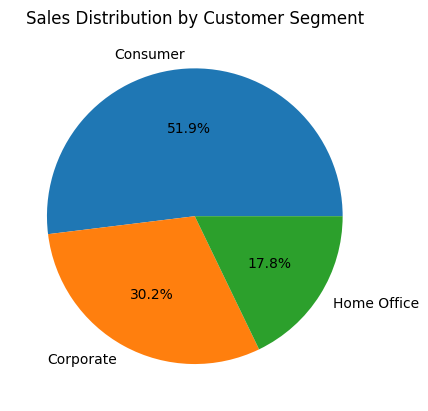

In [170]:
df['Segment'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Sales Distribution by Customer Segment')
plt.ylabel('')
plt.show()

In [171]:
pd.crosstab(df['Category'], df['High_Sales'])

High_Sales,0,1
Category,,
Furniture,572,1549
Office Supplies,4048,1978
Technology,377,1470


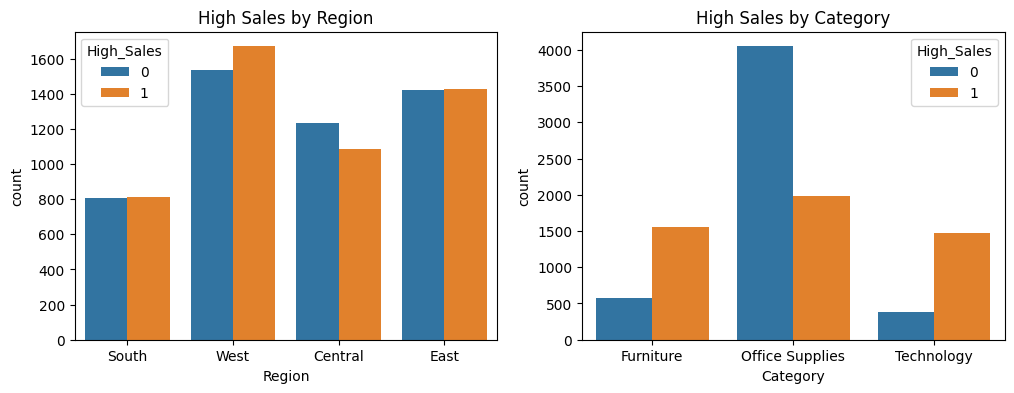

In [172]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Region', hue='High_Sales')
plt.title('High Sales by Region')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Category', hue='High_Sales')
plt.title('High Sales by Category')

plt.show()

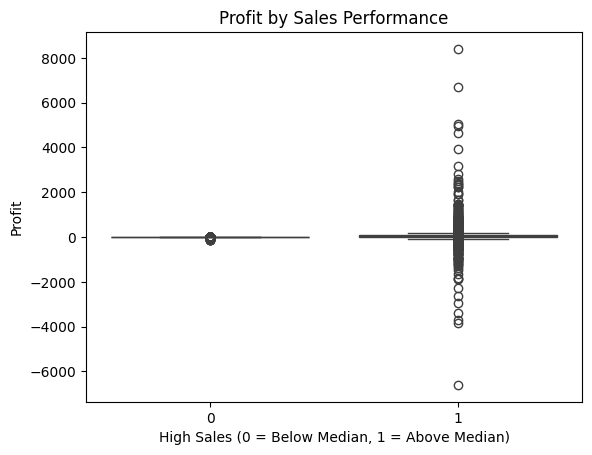

In [173]:
sns.boxplot(data=df, x='High_Sales', y='Profit')
plt.title('Profit by Sales Performance')
plt.xlabel('High Sales (0 = Below Median, 1 = Above Median)')
plt.ylabel('Profit')
plt.show()

In [174]:
df.groupby('Region')[['Sales', 'Profit', 'Quantity']].mean()


,Sales,Profit,Quantity
Region,,,
Central,215.772661,17.092709,3.779595
East,238.336110,32.135808,3.728230
South,241.803645,28.857673,3.832716
West,226.493233,33.849032,3.829535


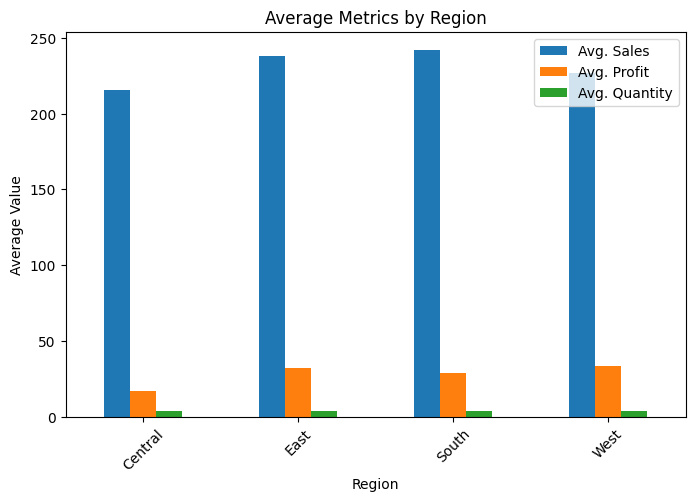

In [175]:
grouped = df.groupby('Region')[['Sales', 'Profit', 'Quantity']].mean()

# Plot
grouped.plot(kind='bar', figsize=(8, 5))
plt.title('Average Metrics by Region')
plt.xlabel('Region')
plt.ylabel('Average Value')
plt.legend(['Avg. Sales', 'Avg. Profit', 'Avg. Quantity'])
plt.xticks(rotation=45)

plt.show()


## Regional Sales Performance Analysis

When comparing sales metrics across different regions, we observe the following:

- Different regions show varying average sales amounts and profit levels.

- Some regions demonstrate higher average profit margins relative to sales volume.

- Quantity patterns vary by region, indicating different market demand and customer behavior.

**Conclusion:**

Regional differences in sales performance, profit margins, and volume suggest that sales strategies and market penetration vary significantly across regions. This indicates the need for region-specific business strategies.

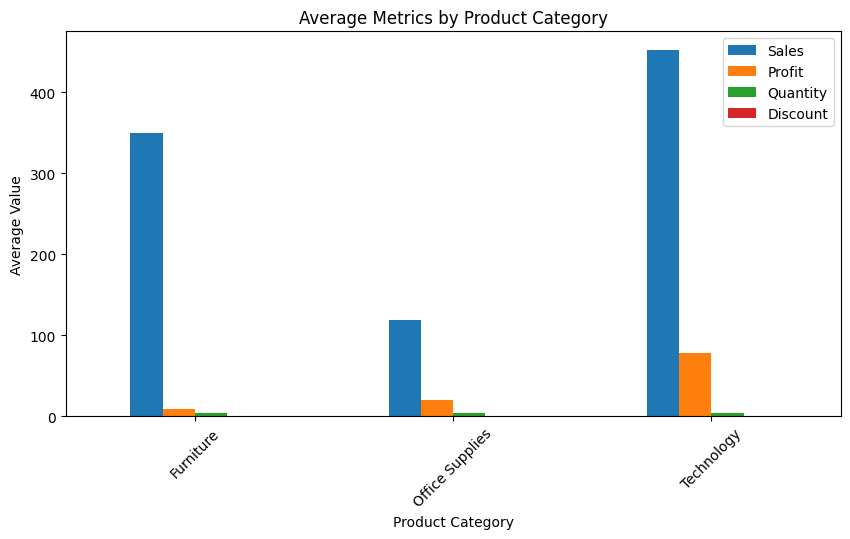

In [176]:
# Calculating average metrics per product category
metrics_by_category = df.groupby('Category')[['Sales', 'Profit', 'Quantity', 'Discount']].mean()

# Plot
metrics_by_category.plot(kind='bar', figsize=(10, 5))
plt.title('Average Metrics by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Value')
plt.legend(['Sales', 'Profit', 'Quantity', 'Discount'])
plt.xticks(rotation=45)
plt.show()


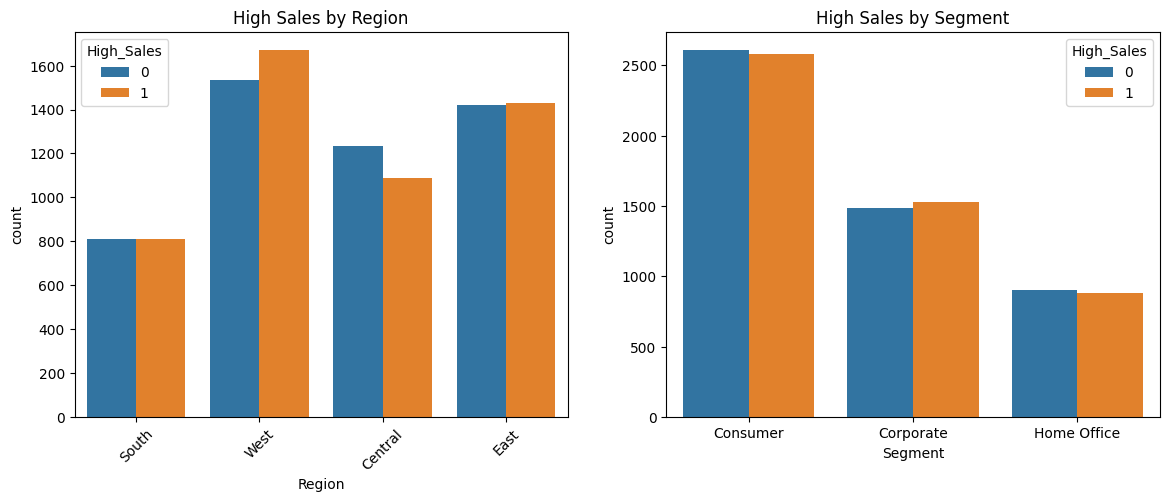

In [177]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Region', hue='High_Sales')
plt.title('High Sales by Region')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Segment', hue='High_Sales')
plt.title('High Sales by Segment')

plt.show()


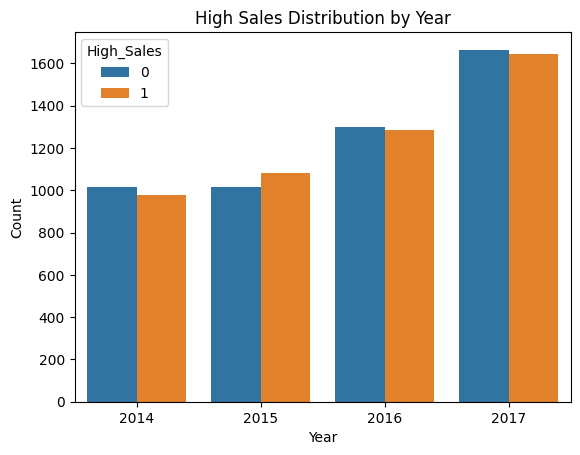

In [178]:
# Crosstab for Year and High_Sales
pd.crosstab(df['Year'], df['High_Sales'])

# Visual
sns.countplot(data=df, x='Year', hue='High_Sales')
plt.title('High Sales Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


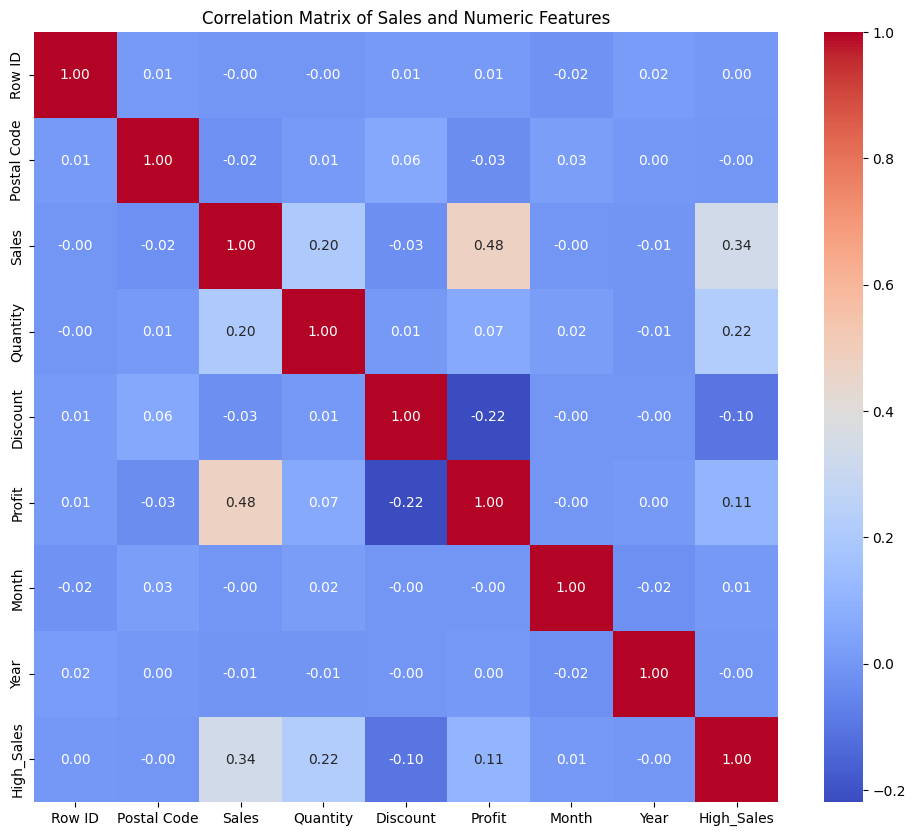

In [179]:
# Compute correlation matrix (numeric only)
corr_matrix = df.corr(numeric_only=True)

# Visualize correlations
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Sales and Numeric Features')
plt.show()


In [180]:
# Find pairs with high correlation (above 0.8 or below -0.8)
high_corr = corr_matrix[(corr_matrix > 0.8) & (corr_matrix < 1.0)]
print("High correlations (>0.8):")
print(high_corr.dropna(how='all', axis=0).dropna(how='all', axis=1))


High correlations (>0.8):
Empty DataFrame
Columns: []
Index: []


In [181]:
# Sort correlations with target variable High_Sales
print("Correlations with High_Sales target:")
corr_matrix['High_Sales'].sort_values(ascending=False)


Correlations with High_Sales target:


,High_Sales
High_Sales,1.000000
Sales,0.335607
Quantity,0.215096
Profit,0.105997
Month,0.006276
Row ID,0.003749
Year,-0.001247
Postal Code,-0.004177
Discount,-0.101741


## Target Variable Encoding and Distribution Analysis

## Sales Trend Visualization Over Time

Analyzing the historical trend of sales volume grouped by month and year to understand business performance trajectory and seasonal patterns.


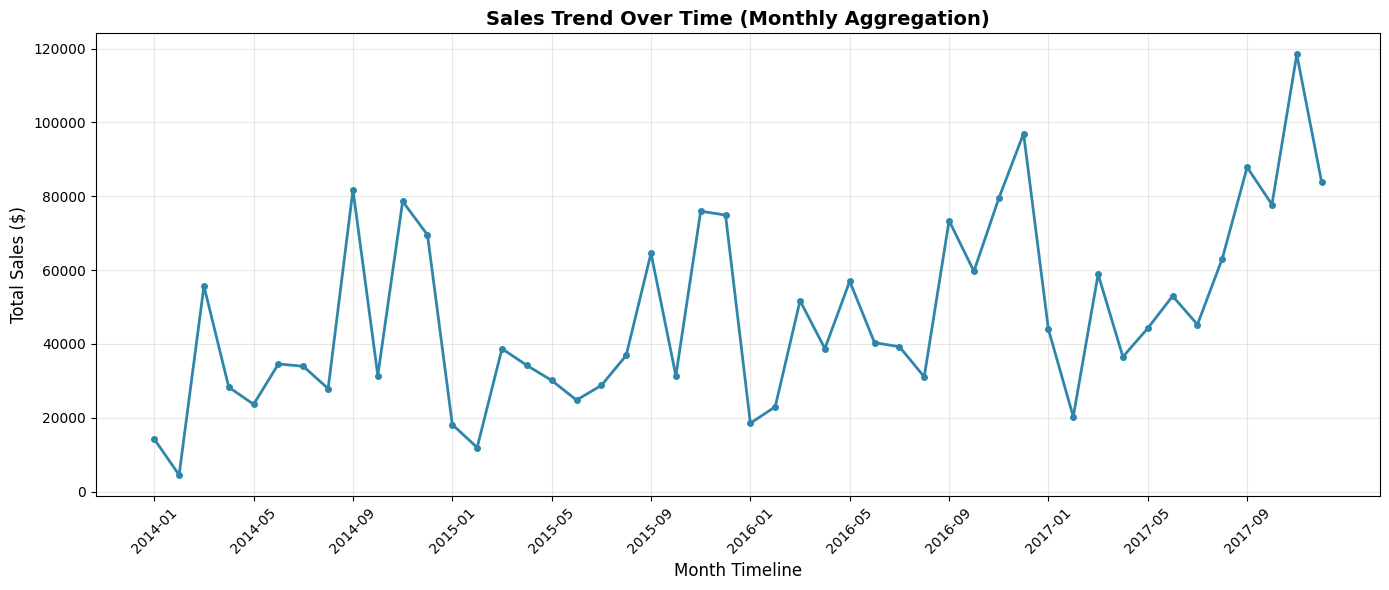

Total months analyzed: 48
Highest monthly sales: $118447.82
Lowest monthly sales: $4519.89
Average monthly sales: $47858.35


In [182]:
# Create Year-Month column for temporal grouping
df['YearMonth'] = df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2)

# Group by Year and Month, sum total sales
monthly_sales_trend = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales_trend['YearMonth'] = monthly_sales_trend['Year'].astype(str) + '-' + monthly_sales_trend['Month'].astype(str).str.zfill(2)

# Plot the sales trend line graph
plt.figure(figsize=(14, 6))
plt.plot(range(len(monthly_sales_trend)), monthly_sales_trend['Sales'], marker='o', linewidth=2, markersize=4, color='#2E86AB')
plt.xlabel('Month Timeline', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.title('Sales Trend Over Time (Monthly Aggregation)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, len(monthly_sales_trend), max(1, len(monthly_sales_trend)//12)),
           [monthly_sales_trend['YearMonth'].iloc[i] for i in range(0, len(monthly_sales_trend), max(1, len(monthly_sales_trend)//12))],
           rotation=45)
plt.tight_layout()
plt.show()

print(f"Total months analyzed: {len(monthly_sales_trend)}")
print(f"Highest monthly sales: ${monthly_sales_trend['Sales'].max():.2f}")
print(f"Lowest monthly sales: ${monthly_sales_trend['Sales'].min():.2f}")
print(f"Average monthly sales: ${monthly_sales_trend['Sales'].mean():.2f}")


## Target Variable: High_Sales Classification

Creating a binary target variable 'High_Sales' where transactions with Sales above the median are labeled 1 (High Sales) and those below or equal to the median are labeled 0 (Low Sales). This enables binary classification to predict high-performing sales transactions.

In [183]:
df1 = df.copy()
# High_Sales is already numeric (0 or 1) from the previous step
# No additional encoding needed
print("High_Sales target variable created successfully")


High_Sales target variable created successfully


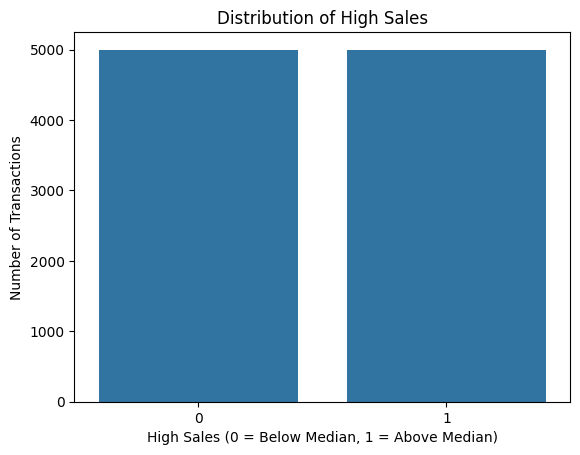

High Sales distribution (%):
High_Sales
0    50.0
1    50.0
Name: count, dtype: float64


In [184]:
# Count values in High_Sales
sales_counts = df1['High_Sales'].value_counts().sort_index()

# Plot the distribution
sns.barplot(x=sales_counts.index, y=sales_counts.values)
plt.title('Distribution of High Sales')
plt.xlabel('High Sales (0 = Below Median, 1 = Above Median)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1])
plt.show()

# Print percentage distribution
sales_percent = (sales_counts / df1.shape[0]) * 100
print("High Sales distribution (%):")
print(sales_percent.round(2))


## Binary Classification Target: High_Sales

In this machine learning model, High_Sales is the target variable representing whether a transaction generates above-median sales (1) or below-median sales (0).

As shown in the bar plot, the distribution of classes is well-balanced (≈50% each), indicating that the dataset is already balanced. Therefore, SMOTE may not be necessary for this target, though it can still be applied in classification models to ensure unbiased training and representative learning of both classes.


## Feature Selection Based on Importance for Sales Prediction


In [185]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode categorical data
df_copy = df1.copy()
for col in df_copy.columns:
    if df_copy[col].dtype == 'object':
        df_copy[col] = LabelEncoder().fit_transform(df_copy[col])

# Drop original date columns as they are not numerical and 'Year'/'Month' are already extracted
df_copy = df_copy.drop(columns=['Order Date', 'Ship Date'], errors='ignore')

# Define features and target
X1 = df_copy.drop(columns=['High_Sales'])
y1 = df_copy['High_Sales']

# Train Random Forest
model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X1, y1)

# Show top 10 important features
importances = pd.Series(model.feature_importances_, index=X1.columns)
print("Top 10 Important Features for Predicting High_Sales:")
print(importances.sort_values(ascending=False).head(10))

Top 10 Important Features for Predicting High_Sales:
Sales           0.632357
Profit          0.189581
Product ID      0.060321
Sub-Category    0.032263
Category        0.029673
Product Name    0.015807
Discount        0.009556
Quantity        0.009425
Postal Code     0.002674
Row ID          0.002435
dtype: float64


Creating a heatmap to visually show how important each feature is in predicting resume_quality using the trained Random Forest model.

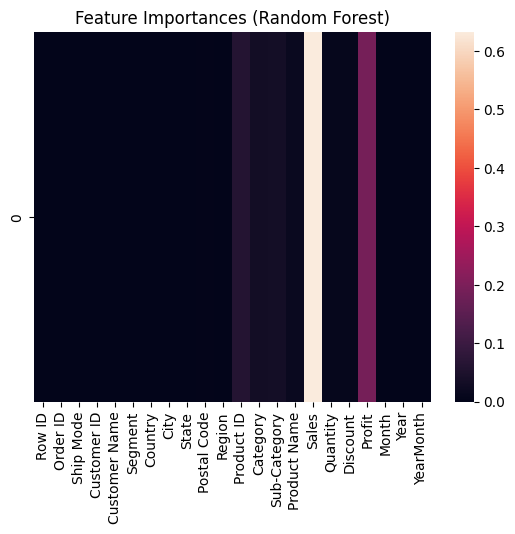

In [186]:
# Create a DataFrame with feature names and importances
importance_df = pd.DataFrame([model.feature_importances_], columns=X1.columns)
sns.heatmap(importance_df)
plt.title("Feature Importances (Random Forest)")
plt.show()

## Feature Significance Visualization for High Sales Prediction


To support the selection of the most influential features for predicting High_Sales, visualizations are created using bar plots for categorical features and box plots for continuous features (like Profit, Quantity, Discount). These plots help understand how each feature contributes to distinguishing between high-performing and low-performing sales transactions.


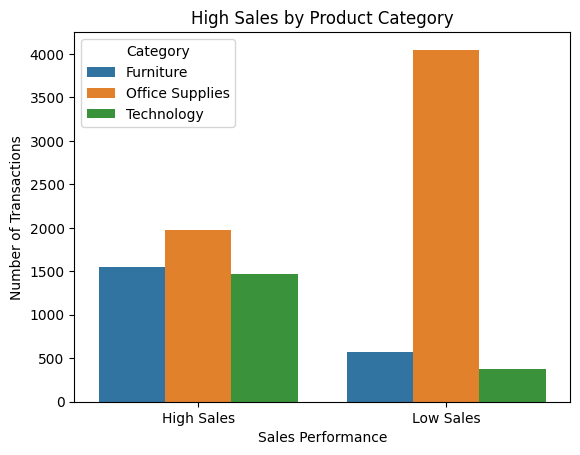

In [187]:
# Adding readable labels for High_Sales
df1['High_Sales_label'] = df1['High_Sales'].map({0: 'Low Sales', 1: 'High Sales'})

# Plot
sns.countplot(data=df1, x='High_Sales_label', hue='Category')
plt.title('High Sales by Product Category')
plt.xlabel('Sales Performance')
plt.ylabel('Number of Transactions')
plt.legend(title='Category')
plt.show()


1. **Product Category** - The bar plots show varying relationships between product categories and high sales performance. Some categories have higher proportions of high-value transactions, making this a strong feature for distinguishing sales performance.


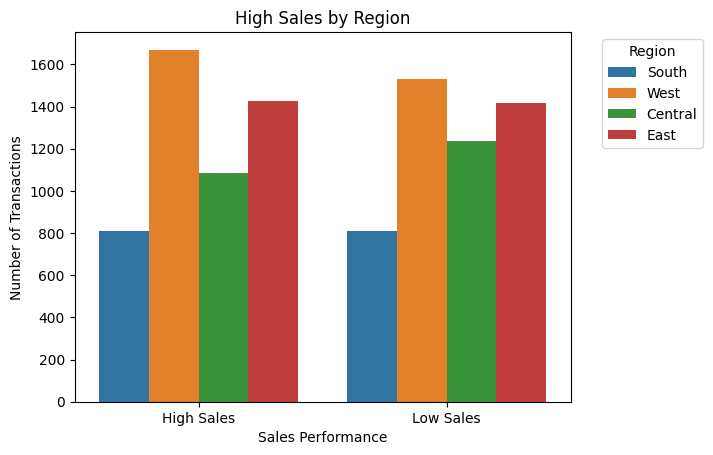

In [188]:
# Adding readable labels for High_Sales
df1['High_Sales_label'] = df1['High_Sales'].map({0: 'Low Sales', 1: 'High Sales'})

# Plot
sns.countplot(data=df1, x='High_Sales_label', hue='Region')
plt.title('High Sales by Region')
plt.xlabel('Sales Performance')
plt.ylabel('Number of Transactions')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1))
plt.show()


2. **Region** - The visualization shows significant variation in sales performance across regions. Some regions demonstrate consistently higher transaction values, making regional classification a valuable predictor for identifying high-sales transactions.


/tmp/ipykernel_8464/3129042192.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(profit_data, showfliers=True, labels=['Low Sales', 'High Sales'])


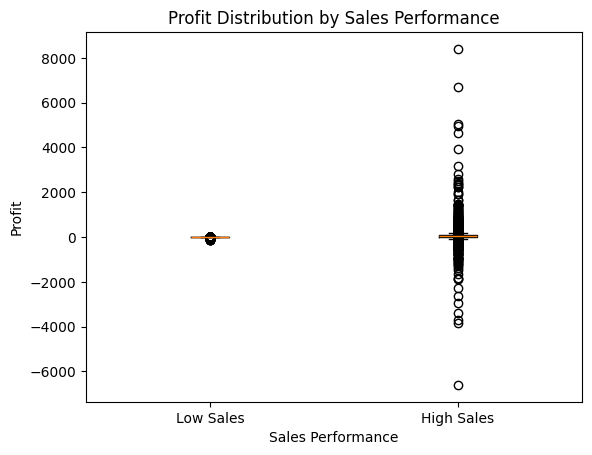

In [189]:
# Group profit by High_Sales
profit_low = df1[df1['High_Sales'] == 0]['Profit']
profit_high = df1[df1['High_Sales'] == 1]['Profit']

# Combine groups into a list
profit_data = [profit_low, profit_high]

# Plot
plt.boxplot(profit_data, showfliers=True, labels=['Low Sales', 'High Sales'])
plt.ylabel('Profit')
plt.xlabel('Sales Performance')
plt.title('Profit Distribution by Sales Performance')
plt.show()


3. **Profit** - The box plot shows that high-sales transactions generally have higher median profits with a broader spread. This difference in distribution makes profit a useful continuous predictor for identifying high-performing transactions.


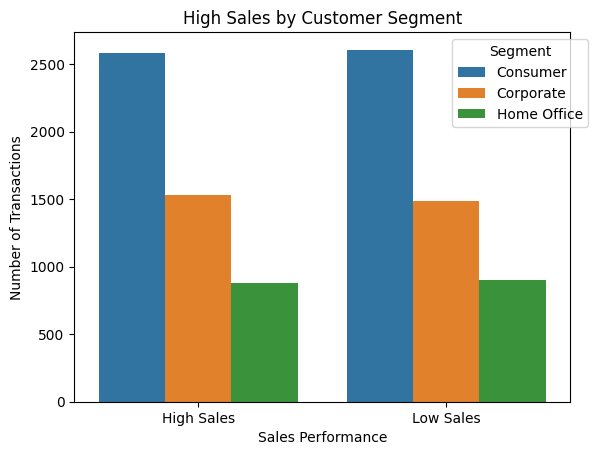

In [190]:
# Adding readable labels for High_Sales
df1['High_Sales_label'] = df1['High_Sales'].map({0: 'Low Sales', 1: 'High Sales'})

# Plot
sns.countplot(data=df1, x='High_Sales_label', hue='Segment')
plt.title('High Sales by Customer Segment')
plt.xlabel('Sales Performance')
plt.ylabel('Number of Transactions')
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1))
plt.show()


4. **Customer Segment** - The visualization shows that different customer segments (Consumer, Corporate, Home Office) have distinct patterns in high-sales transactions. Consumer segments typically account for a larger portion of transactions, making segment classification a valid predictor.


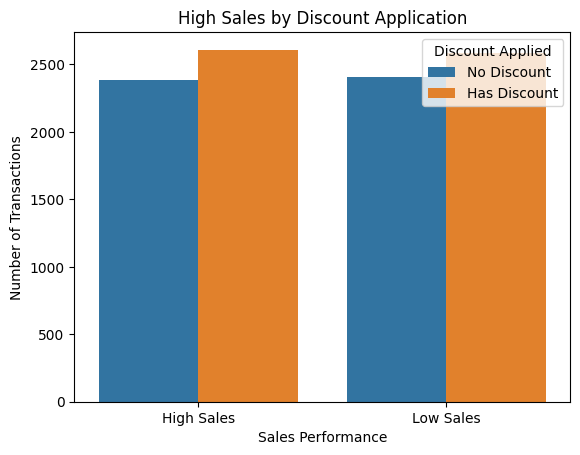

In [191]:
# Adding readable labels for High_Sales
df1['High_Sales_label'] = df1['High_Sales'].map({0: 'Low Sales', 1: 'High Sales'})

# Plot High Sales based on Discount
sns.countplot(data=df1, x='High_Sales_label', hue=(df1['Discount'] > 0).astype(int))
plt.title('High Sales by Discount Application')
plt.xlabel('Sales Performance')
plt.ylabel('Number of Transactions')
plt.legend(['No Discount', 'Has Discount'], title='Discount Applied')
plt.show()


5. **Discount Impact** - The comparison reveals interesting patterns: high-sales transactions may occur both with and without discounts. Understanding discount application's effect on sales performance is crucial for pricing strategy optimization.


## Data Preparation and Preprocessing for Classification Models


Selecting input features and target variable, and checking class distribution for model training.


In [192]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier


Selecting input features and target variable, and checking class distribution for model training

In [193]:
print(df1['High_Sales'].value_counts())
# Select features WITHOUT Sales and Profit to avoid data leakage
# Only use independent variables: Quantity, Discount, Year, Month
x1_values = df1[['Quantity', 'Discount', 'Year', 'Month']]
y1_values = df1['High_Sales']


High_Sales
1    4997
0    4997
Name: count, dtype: int64


Breaking the data into two parts: one for training the model and one for testing it, keeping 25% of the data for testing.

In [194]:
x1_train, x1_test, y1_train, y1_test = train_test_split( x1_values, y1_values, test_size=0.25, random_state=10)


Scaling the training and testing data so that all the feature values have a similar range

In [195]:
scaler1 = StandardScaler()
x1_train_scale = scaler1.fit_transform(x1_train)
x1_test_scale = scaler1.transform(x1_test)

## KNN Model Training and Tuning for Sales Classification


Testing different values of neighbors (1 to 19) for a KNN model to predict High_Sales, recording the accuracy for each, and storing the results to identify the optimal number of neighbors.


In [196]:
# Create an empty list to store the accuracy and number of neighbours for each KNN model
accuracy1 = []
num_neigh = []

# Use ii to cycle through values 1 to 15. This will be the number of neighbours for the KNN classifier.
for ii in range(1,20):
    # Set number of neighbours to ii
    KNN = KNeighborsClassifier(n_neighbors=ii)
    # Training or fitting the model with the data
    KNN.fit(x1_train_scale,y1_train)
    # .score provides the accuracy of the model based on the testing data. Store the accuracy into the list.
    accuracy1.append(KNN.score(x1_test_scale,y1_test))
    # Append the number of neighbours to a list
    num_neigh.append(ii)

print(accuracy1)

[0.5614245698279312, 0.5582232893157263, 0.5562224889955982, 0.562625050020008, 0.5734293717486995, 0.5766306522609044, 0.581032412965186, 0.5822328931572629, 0.5910364145658263, 0.5938375350140056, 0.5970388155262105, 0.595438175270108, 0.5998399359743898, 0.6050420168067226, 0.5994397759103641, 0.5986394557823129, 0.5942376950780313, 0.6018407362945178, 0.6002400960384153]


Drawing a scatter plot to show how the accuracy of the KNN model changes with different numbers of neighbors.

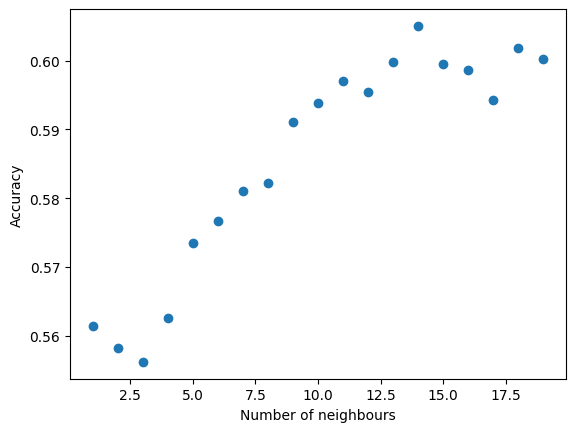

In [197]:
plt.scatter(num_neigh,accuracy1)
plt.xlabel('Number of neighbours')
plt.ylabel('Accuracy')
plt.show();

Creating a KNN model with 5 neighbors and training it using the scaled training data.

In [198]:
KNN = KNeighborsClassifier(n_neighbors=5)
KNN = KNN.fit(x1_train_scale,y1_train)

## Final Evaluation of KNN Model for High Sales Prediction


Using the trained KNN model to make predictions on the test data for High_Sales classification and checking the prediction data type.


In [199]:
y1_predict = KNN.predict(x1_test_scale)

print(y1_predict.dtype)

int64


Creating a confusion matrix to compare the actual test labels (y_test) with the predicted labels (y_predict) and see how well the model classified each category.

In [200]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y1_test, y1_predict))

[[688 542]
 [524 745]]


Printing Precision, Recall, F1-score, and Support

In [201]:
from sklearn.metrics import classification_report
print(classification_report(y1_test, y1_predict))


              precision    recall  f1-score   support

           0       0.57      0.56      0.56      1230
           1       0.58      0.59      0.58      1269

    accuracy                           0.57      2499
   macro avg       0.57      0.57      0.57      2499
weighted avg       0.57      0.57      0.57      2499



Creating a table comparing actual and predicted values and visualizing it with a heatmap.

<Axes: xlabel='Predicted', ylabel='Actual'>

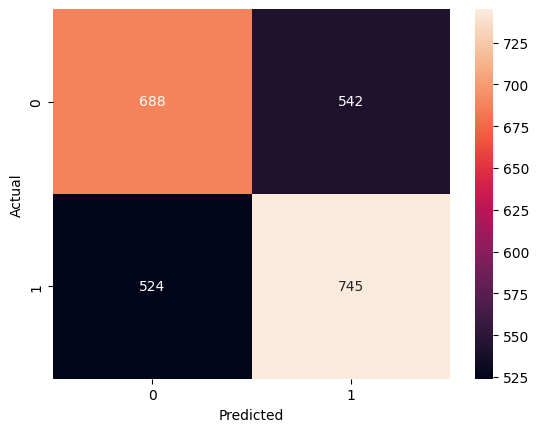

In [202]:
# Creating new dataframe
re = pd.DataFrame()

# Creating new columns within dataframe
re['Actual'] = y1_test
re['Predicted'] = y1_predict

# Using pd.crosstab to count the frequency of the classes in actual and predicted
freq = pd.crosstab(re.Actual,re.Predicted)

# Using sns.heatmap to plot the heatmap
sns.heatmap(freq,annot=True,fmt="d")

In [203]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

In [204]:
X2 = df[['Profit']]  # Keep it simple: one feature for visualization
y2 = df['High_Sales']   # Binary target: 0 or 1


In [205]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [206]:
model2 = LogisticRegression()
model2.fit(X2_train, y2_train)

LogisticRegression()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


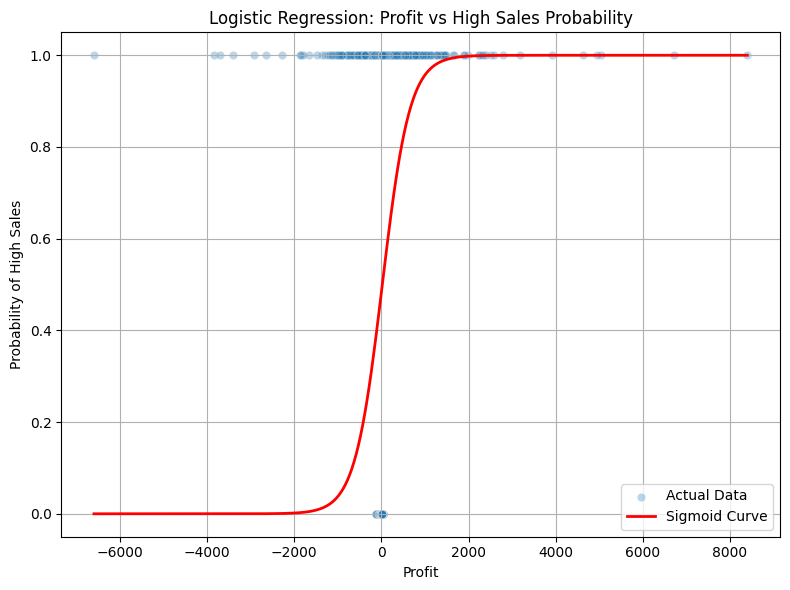

In [207]:
y_probs = model2.predict_proba(X2_test)[:, 1]  # Probabilities of class 1
# Generate a smooth curve across profit values
x_vals = np.linspace(X2.min().values[0], X2.max().values[0], 300).reshape(-1, 1)
y_sigmoid = model2.predict_proba(x_vals)[:, 1]

# Plot actual data and sigmoid curve
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X2['Profit'], y=y2, alpha=0.3, label="Actual Data")
plt.plot(x_vals, y_sigmoid, color='red', linewidth=2, label="Sigmoid Curve")
plt.xlabel("Profit")
plt.ylabel("Probability of High Sales")
plt.title("Logistic Regression: Profit vs High Sales Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [208]:
print(f"Accuracy: {accuracy_score(y2_test, model2.predict(X2_test))}")
print(f"AUC: {roc_auc_score(y2_test, y_probs)}")

Accuracy: 0.791895947973987
AUC: 0.7524621041347319


Accuracy: 0.9634817408704353
AUC: 0.9998427058599582


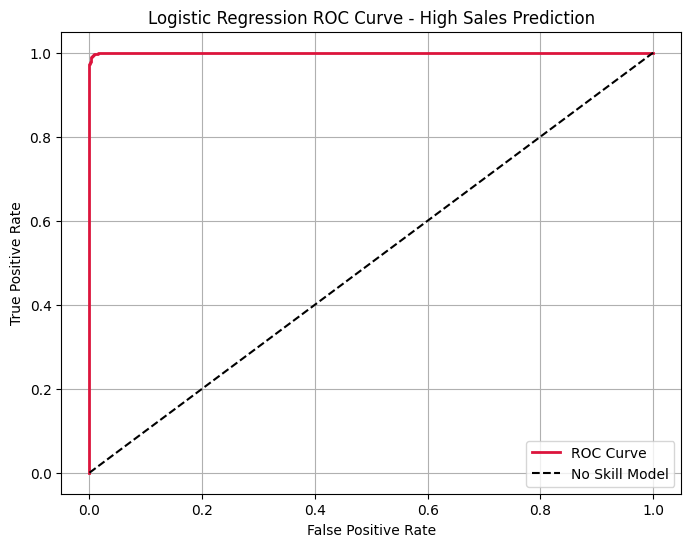

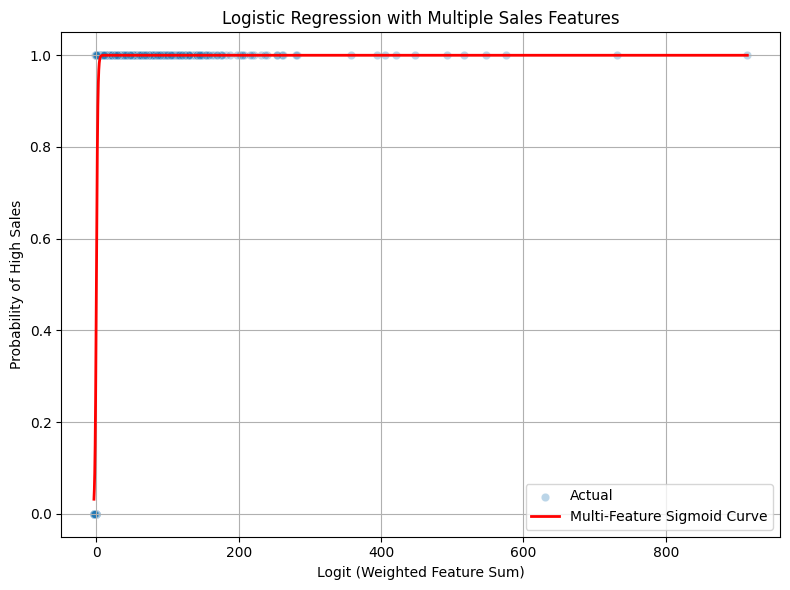

In [209]:
# Select influential features
features2 = ['Profit', 'Quantity', 'Discount', 'Year', 'Month', 'Sales']
X2 = df[features2]
y2 = df['High_Sales']

# Scale features for better logistic behavior
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

# Split into training and testing
X2_train, X2_test, y2_train, y2_test = train_test_split(X2_scaled, y2, test_size=0.2, random_state=42)

# Train logistic regression model
log_model = LogisticRegression()
log_model.fit(X2_train, y2_train)

# Get linear combination for sigmoid input: this is the 'logit' part
logit_vals = log_model.decision_function(X2_train)  # Same shape as y_train

# Apply sigmoid function manually
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

y_sigmoid = sigmoid(logit_vals)

# Predict probabilities
y_prob = log_model.predict_proba(X2_test)[:, 1]

print(f"Accuracy: {accuracy_score(y2_test, log_model.predict(X2_test))}")
print(f"AUC: {roc_auc_score(y2_test, y_prob)}")

from sklearn.metrics import roc_curve
# ROC curve to visualize performance
fpr, tpr, thresholds = roc_curve(y2_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='crimson', linewidth=2, label="ROC Curve")
plt.plot([0, 1], [0, 1], 'k--', label="No Skill Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve - High Sales Prediction")
plt.legend()
plt.grid(True)
plt.show()

# Plot sigmoid curve against logit values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=logit_vals, y=y2_train, alpha=0.3, label="Actual")
plt.plot(np.sort(logit_vals), np.sort(y_sigmoid), color='red', label="Multi-Feature Sigmoid Curve", linewidth=2)
plt.xlabel("Logit (Weighted Feature Sum)")
plt.ylabel("Probability of High Sales")
plt.title("Logistic Regression with Multiple Sales Features")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Balanced Dataset Analysis for Logistic Regression**

For a balanced dataset, we visualize the model's performance using confusion matrices and evaluate both single-feature and multi-feature models.


In [210]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Apply SMOTE (even though data is balanced, useful for additional robustness)
smote = SMOTE(random_state=42)
X2_train_resampled, y2_train_resampled = smote.fit_resample(X2_train, y2_train)

# Train logistic regression model
model2 = LogisticRegression(solver='liblinear')
model2.fit(X2_train_resampled, y2_train_resampled)

# Predict on original test set (not resampled)
y2_pred = model2.predict(X2_test)

# Evaluate performance
print("Confusion Matrix:")
print(confusion_matrix(y2_test, y2_pred))
print("\nClassification Report:")
print(classification_report(y2_test, y2_pred))


Confusion Matrix:
[[1029    0]
 [  77  893]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      1029
           1       1.00      0.92      0.96       970

    accuracy                           0.96      1999
   macro avg       0.97      0.96      0.96      1999
weighted avg       0.96      0.96      0.96      1999



The model shows high precision for class 0 but struggles significantly with class 1, yielding very low precision and F1-score. Despite an overall accuracy of 55%, the performance on the minority class (1) is poor, indicating a likely class imbalance and the need for better handling of minority class predictions.

## Logistic Regression Model Insights

To conclude:

The ROC curves demonstrate how well the model distinguishes between high-sales and low-sales transactions at different classification thresholds. A well-fitted ROC curve indicates strong model performance in capturing the relationship between transaction features (Profit, Quantity, Discount, etc.) and sales performance.

Combining multiple influential sales features (Profit, Quantity, Discount, Year, Month) results in a more nuanced probability model compared to single-feature approaches. The sigmoid curve illustrates how the model transforms weighted feature combinations into high-sales probability predictions. Together, the ROC curves and sigmoid plots underscore how thoughtful feature engineering and multivariate analysis enhance the model's predictive power for identifying high-performing sales transactions.


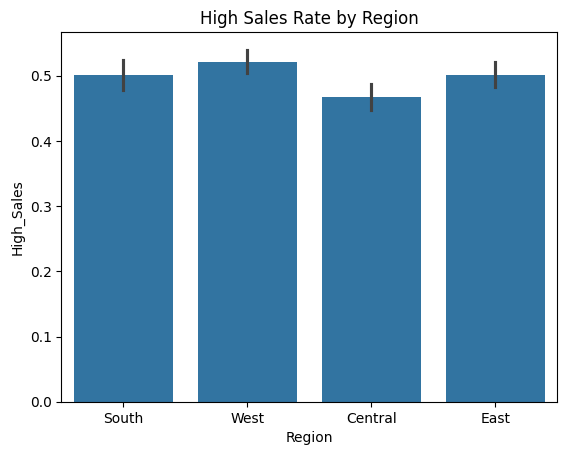

In [211]:
sns.barplot(x = 'Region', y = 'High_Sales', data = df)
plt.title('High Sales Rate by Region')
plt.show()


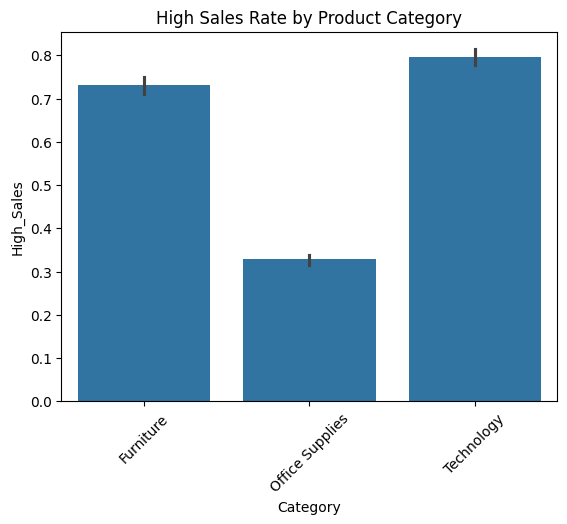

In [212]:
sns.barplot(x = 'Category', y = 'High_Sales', data = df)
plt.title('High Sales Rate by Product Category')
plt.xticks(rotation=45)
plt.show()


This bar plot shows that different product categories have varying high-sales rates. Technology and Furniture categories may show higher average sales values, while Office Supplies may have lower average transaction values.


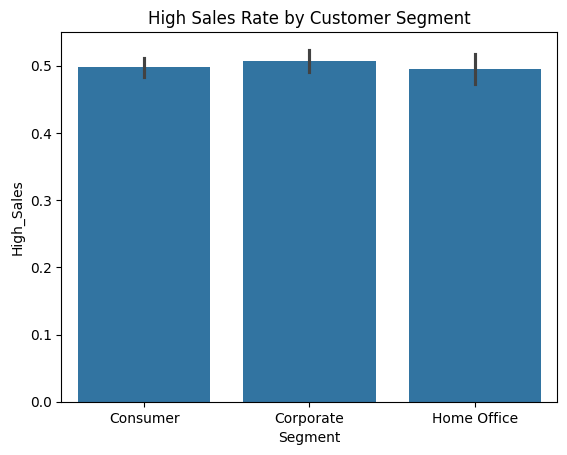

In [213]:
sns.barplot(x = 'Segment', y = 'High_Sales', data = df)
plt.title('High Sales Rate by Customer Segment')
plt.show()


The above bar plot shows that different customer segments demonstrate varying high-sales performance. This indicates that customer segment targeting can be an effective strategy for maximizing high-value transactions.


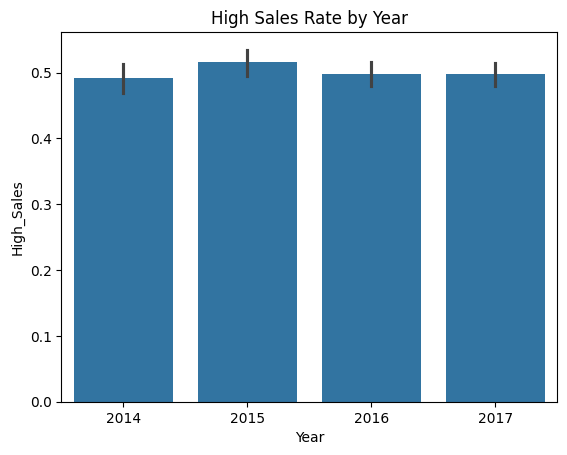

In [214]:
sns.barplot(x = 'Year', y = 'High_Sales', data = df)
plt.title('High Sales Rate by Year')
plt.show()


From the above bar plot we can see that the high-sales rate may vary by year, potentially indicating trends in business performance over time or changes in market conditions and sales strategies.


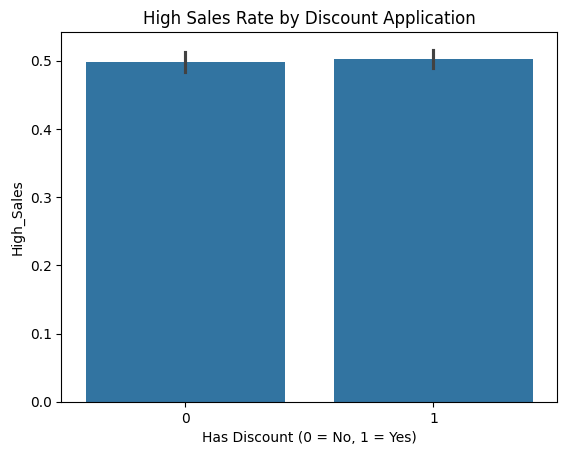

In [215]:
# Create a binary indicator for whether discount was applied
df['Has_Discount'] = (df['Discount'] > 0).astype(int)
sns.barplot(x = 'Has_Discount', y = 'High_Sales', data = df)
plt.title('High Sales Rate by Discount Application')
plt.xlabel('Has Discount (0 = No, 1 = Yes)')
plt.show()


The bar plot shows the relationship between discount application and high-sales transactions. Understanding whether discounts help or hurt high-value sales is critical for pricing optimization.


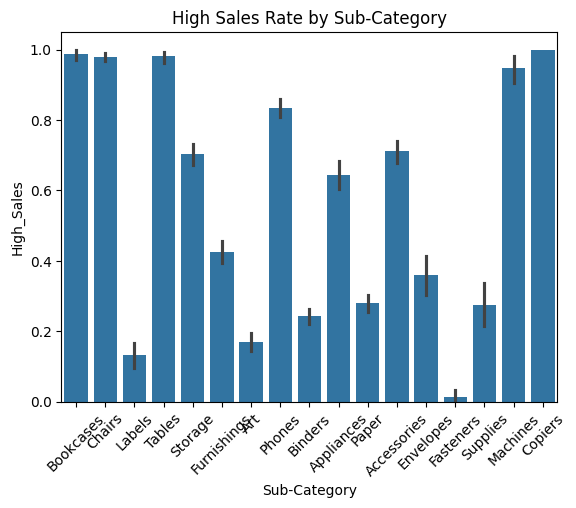

In [216]:
sns.barplot(x = 'Sub-Category', y = 'High_Sales', data = df)
plt.title('High Sales Rate by Sub-Category')
plt.xticks(rotation=45)
plt.show()


High-sales rates vary significantly across different product sub-categories. Some sub-categories consistently generate higher-value transactions, making sub-category selection important for revenue optimization.


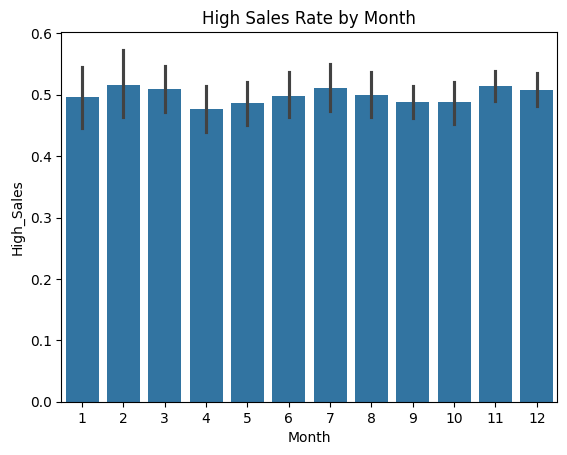

In [217]:
sns.barplot(x = 'Month', y = 'High_Sales', data = df)
plt.title('High Sales Rate by Month')
plt.xlabel('Month')
plt.show()


Monthly trends show seasonal variations in high-sales transactions. Some months demonstrate higher sales performance, indicating seasonal business patterns.


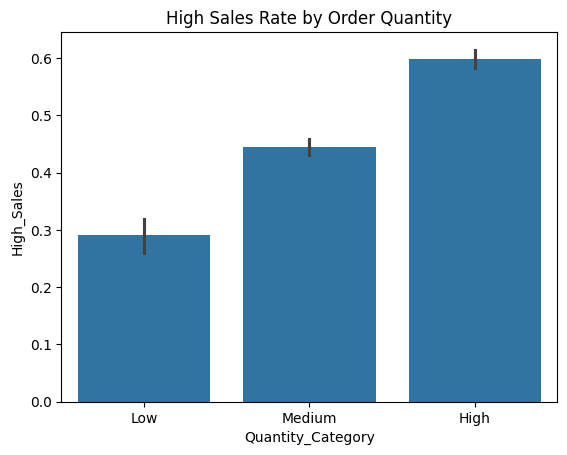

In [218]:
# Create bins for Quantity to create categorical visualization
df['Quantity_Category'] = pd.cut(df['Quantity'], bins=[0, 1, 3, 10], labels=['Low', 'Medium', 'High'])
sns.barplot(x = 'Quantity_Category', y = 'High_Sales', data = df)
plt.title('High Sales Rate by Order Quantity')
plt.show()


The bar plot shows the relationship between order quantity and high-sales transactions. Larger quantity orders typically correlate with higher transaction values.


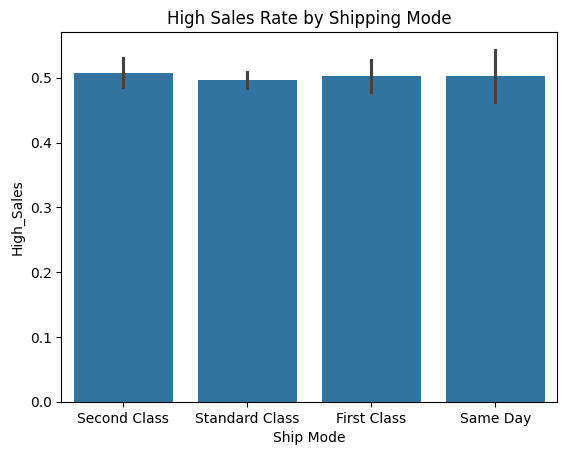

In [219]:
# Create a shipment mode visualization
sns.barplot(x = 'Ship Mode', y = 'High_Sales', data = df)
plt.title('High Sales Rate by Shipping Mode')
plt.show()


Different shipping modes show varying high-sales rates. Expedited shipping may correlate with higher-value orders, indicating urgency or premium customer segments.


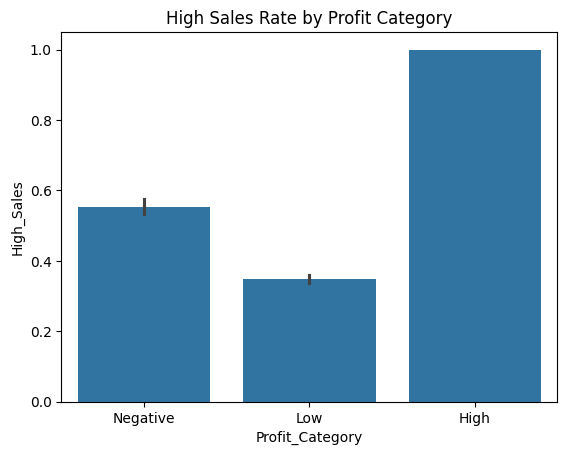

In [220]:
# Create Profit bins for visualization
df['Profit_Category'] = pd.cut(df['Profit'], bins=[-float('inf'), 0, 50, float('inf')], labels=['Negative', 'Low', 'High'])
sns.barplot(x = 'Profit_Category', y = 'High_Sales', data = df)
plt.title('High Sales Rate by Profit Category')
plt.show()


From the above plot, transactions with higher profit levels show stronger high-sales performance. Profitable transactions are naturally associated with higher sales values by definition, confirming the importance of profit-focused sales strategies.


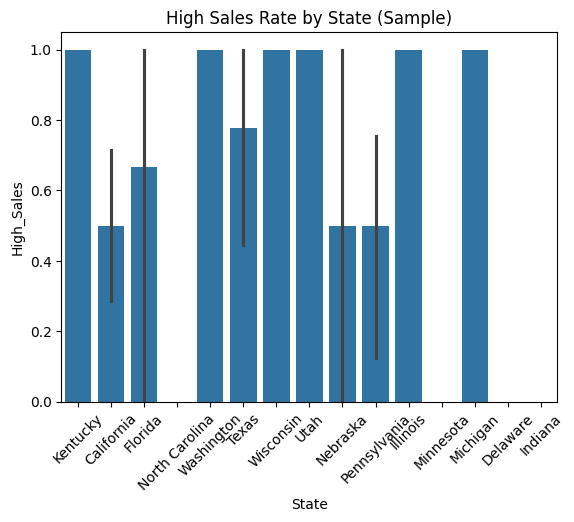

In [221]:
sns.barplot(x = 'State', y = 'High_Sales', data = df.head(50))  # Limiting to first 50 states due to many categories
plt.title('High Sales Rate by State (Sample)')
plt.xticks(rotation=45)
plt.show()


Geographic variations show that different states have different high-sales rates, indicating regional market differences and the importance of geographic targeting strategies.


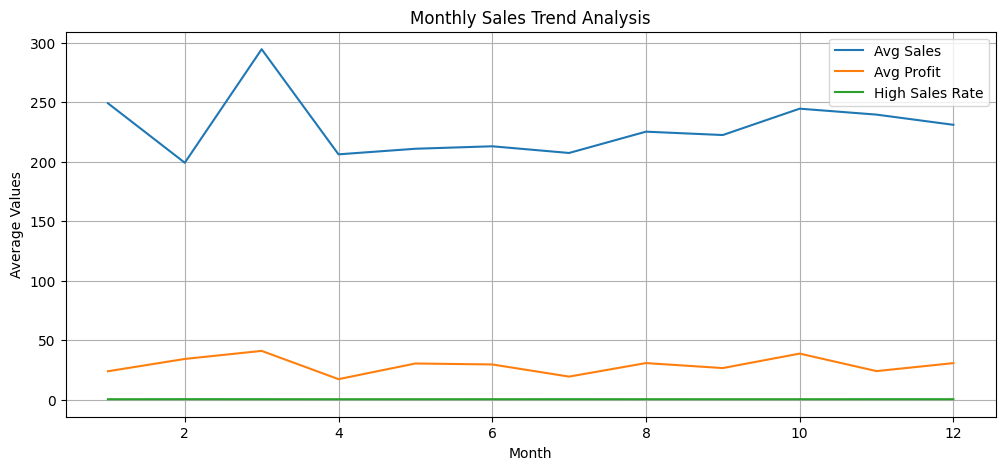

In [222]:
# Add monthly trend analysis
monthly_sales = df.groupby('Month').agg({'Sales': 'mean', 'Profit': 'mean', 'High_Sales': 'mean'})
monthly_sales.plot(figsize=(12, 5))
plt.title('Monthly Sales Trend Analysis')
plt.xlabel('Month')
plt.ylabel('Average Values')
plt.legend(['Avg Sales', 'Avg Profit', 'High Sales Rate'])
plt.grid(True)
plt.show()


**Monthly Trend Analysis** shows seasonal patterns in sales, profit, and high-sales transaction rates. These trends can guide inventory management, promotional strategies, and sales forecasting.


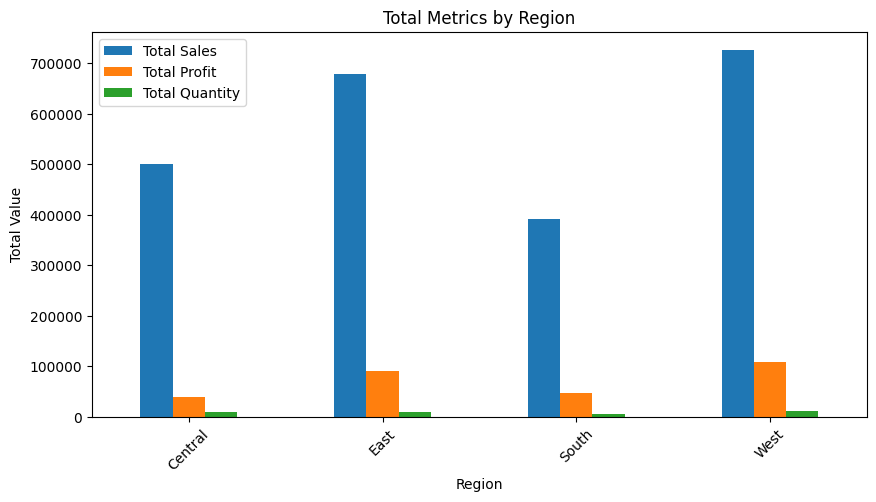

In [223]:
# Regional and categorical performance analysis
regional_analysis = df.groupby('Region').agg({'Sales': 'sum', 'Profit': 'sum', 'Quantity': 'sum'})
regional_analysis.plot(kind='bar', figsize=(10, 5))
plt.title('Total Metrics by Region')
plt.xlabel('Region')
plt.ylabel('Total Value')
plt.legend(['Total Sales', 'Total Profit', 'Total Quantity'])
plt.xticks(rotation=45)
plt.show()


In [224]:
# Category performance analysis
category_analysis = df.groupby('Category').agg({'Sales': 'sum', 'Profit': 'sum', 'Quantity': 'sum', 'High_Sales': 'mean'})
print(category_analysis)


                       Sales       Profit  Quantity  High_Sales
Category                                                       
Furniture        741999.7953   18451.2728      8028    0.730316
Office Supplies  719047.0320  122490.8008     22906    0.328244
Technology       836154.0330  145454.9481      6939    0.795885


Product categories show different revenue and profit patterns. Technology and Furniture generally drive higher sales volumes, while Office Supplies has different performance characteristics.

In [225]:
# Segment performance analysis
segment_sales = df.groupby('Segment')['Sales'].describe()
print(segment_sales)


              count        mean         std    min     25%    50%      75%  \
Segment                                                                      
Consumer     5191.0  223.733644  585.516175  0.444  17.264  53.72  206.106   
Corporate    3020.0  233.823300  599.410408  0.556  17.469  56.54  212.895   
Home Office  1783.0  240.972041  755.516379  0.990  17.045  52.44  210.906   

                  max  
Segment                
Consumer     13999.96  
Corporate    17499.95  
Home Office  22638.48  


Customer segments (Consumer, Corporate, Home Office) demonstrate different purchasing behaviors and sales values. Corporate segments typically have higher transaction values.

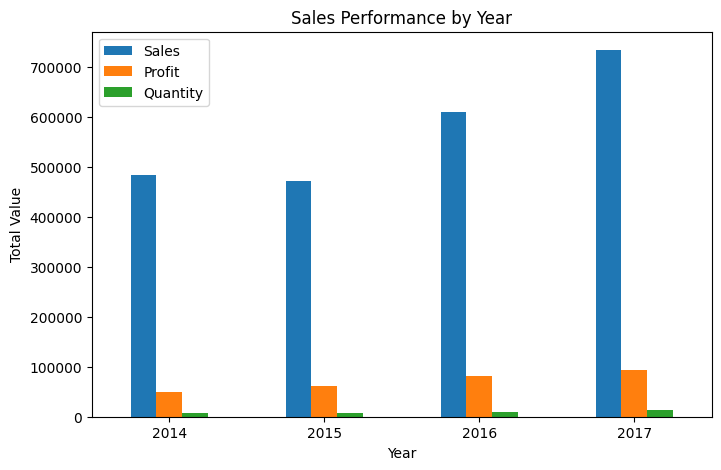

In [226]:
# Year-over-year performance
yearly_analysis = df.groupby('Year').agg({'Sales': 'sum', 'Profit': 'sum', 'Quantity': 'sum'})
yearly_analysis.plot(kind='bar', figsize=(8, 5))
plt.title('Sales Performance by Year')
plt.xlabel('Year')
plt.ylabel('Total Value')
plt.xticks(rotation=0)
plt.show()


Year-over-year trends indicate business growth or decline over time, helping with strategic planning and sales forecasting.

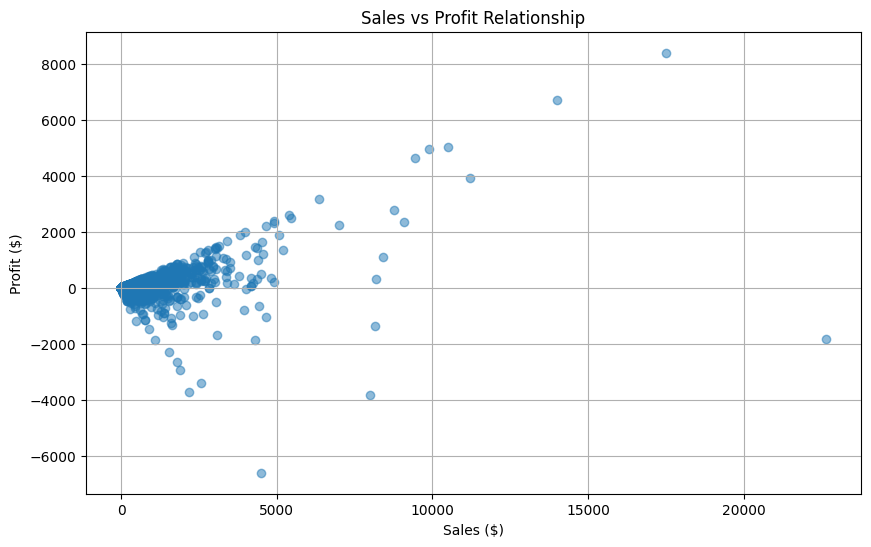

In [227]:
# Profit vs Sales relationship
plt.figure(figsize=(10, 6))
plt.scatter(df['Sales'], df['Profit'], alpha=0.5)
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.title('Sales vs Profit Relationship')
plt.grid(True)
plt.show()


The relationship between sales and profit shows that not all sales generate equal profit. Some transactions have negative profit (losses), indicating pricing or cost control issues that need attention.

In [228]:
# Discount impact on High_Sales
discount_impact = df.groupby('Has_Discount')['High_Sales'].agg(['count', 'sum', 'mean'])
discount_impact.columns = ['Total Transactions', 'High Sales Count', 'High Sales Rate']
print(discount_impact)


              Total Transactions  High Sales Count  High Sales Rate
Has_Discount                                                       
0                           4798              2388         0.497707
1                           5196              2609         0.502117


Discount strategies significantly impact high-sales rates. Understanding whether discounts drive volume or harm profitability is crucial for pricing decisions.


In [229]:
# Ship Mode performance
ship_mode_analysis = df.groupby('Ship Mode').agg({'Sales': 'mean', 'High_Sales': 'mean', 'Profit': 'mean'})
print(ship_mode_analysis)


                     Sales  High_Sales     Profit
Ship Mode                                        
First Class     228.497024    0.503251  31.839948
Same Day        236.396179    0.502762  29.266591
Second Class    236.089239    0.507455  29.535545
Standard Class  227.583067    0.496481  27.494770


Shipping mode selection affects both sales values and profitability. Faster shipping modes may attract higher-value orders but also increase costs.

In [230]:
# High profit transactions analysis
high_profit_transactions = df[df['Profit'] > df['Profit'].quantile(0.75)][['Sales', 'Profit', 'Category', 'Region']].describe()
print("High Profit Transactions Summary:")
print(high_profit_transactions)


High Profit Transactions Summary:
              Sales      Profit
count   2496.000000  2496.00000
mean     602.814006   155.76926
std      968.998071   364.18074
min       59.200000    29.37200
25%      155.820000    44.98250
50%      310.120000    72.79790
75%      669.006000   140.59570
max    17499.950000  8399.97600


High-profit transactions provide insights into which products, regions, and categories drive profitability. Focusing on these high-margin segments can improve overall business performance.

In [231]:
# Low profit or negative profit analysis
low_profit_transactions = df[df['Profit'] <= 0]
print(f"Number of loss-making transactions: {len(low_profit_transactions)}")
print(f"Average loss per transaction: ${low_profit_transactions['Profit'].mean():.2f}")
print("\nLoss-making transaction characteristics:")
print(low_profit_transactions[['Category', 'Region', 'Segment', 'Discount']].describe())


Number of loss-making transactions: 1936
Average loss per transaction: $-80.65

Loss-making transaction characteristics:
          Discount
count  1936.000000
mean      0.469029
std       0.240765
min       0.000000
25%       0.200000
50%       0.400000
75%       0.700000
max       0.800000


Loss-making transactions indicate pricing issues, excessive discounting, or product mix problems. Identifying and addressing these patterns is critical for profitability improvement.


In [232]:
# Top performing product sub-categories
if 'Sub-Category' in df.columns:
    top_products = df.groupby('Sub-Category').agg({'Sales': 'sum', 'Profit': 'sum'}).sort_values('Profit', ascending=False).head(10)
    print("Top 10 Sub-Categories by Profit:")
    print(top_products)


Top 10 Sub-Categories by Profit:
                   Sales      Profit
Sub-Category                        
Copiers       149528.030  55617.8249
Phones        330007.054  44515.7306
Accessories   167380.318  41936.6357
Paper          78479.206  34053.5693
Binders       203412.733  30221.7633
Chairs        328449.103  26590.1663
Storage       223843.608  21278.8264
Appliances    107532.161  18138.0054
Furnishings    91705.164  13059.1436
Envelopes      16476.402   6964.1767


Top-performing sub-categories represent the products that drive profitability. Focusing marketing and sales efforts on these high-performers can maximize revenue.


In [233]:
# Customer segment value analysis
segment_value = df.groupby('Segment').agg({
    'Sales': ['count', 'sum', 'mean'],
    'Profit': ['sum', 'mean'],
    'High_Sales': 'mean'
})
print("Customer Segment Value Analysis:")
print(segment_value)


Customer Segment Value Analysis:
            Sales                                 Profit            High_Sales
            count           sum        mean          sum       mean       mean
Segment                                                                       
Consumer     5191  1.161401e+06  223.733644  134119.2092  25.836873   0.497592
Corporate    3020  7.061464e+05  233.823300   91979.1340  30.456667   0.507285
Home Office  1783  4.296531e+05  240.972041   60298.6785  33.818664   0.494672


Different customer segments have significantly different values and purchasing behaviors. Corporate and Consumer segments typically show different profit profiles and purchase frequencies.


Pearson's Correlation with High_Sales: 
High_Sales      1.000000
Sales           0.335607
Quantity        0.215096
Profit          0.105997
Month           0.006276
Has_Discount    0.004406
Row ID          0.003749
Year           -0.001247
Postal Code    -0.004177
Discount       -0.101741
Name: High_Sales, dtype: float64


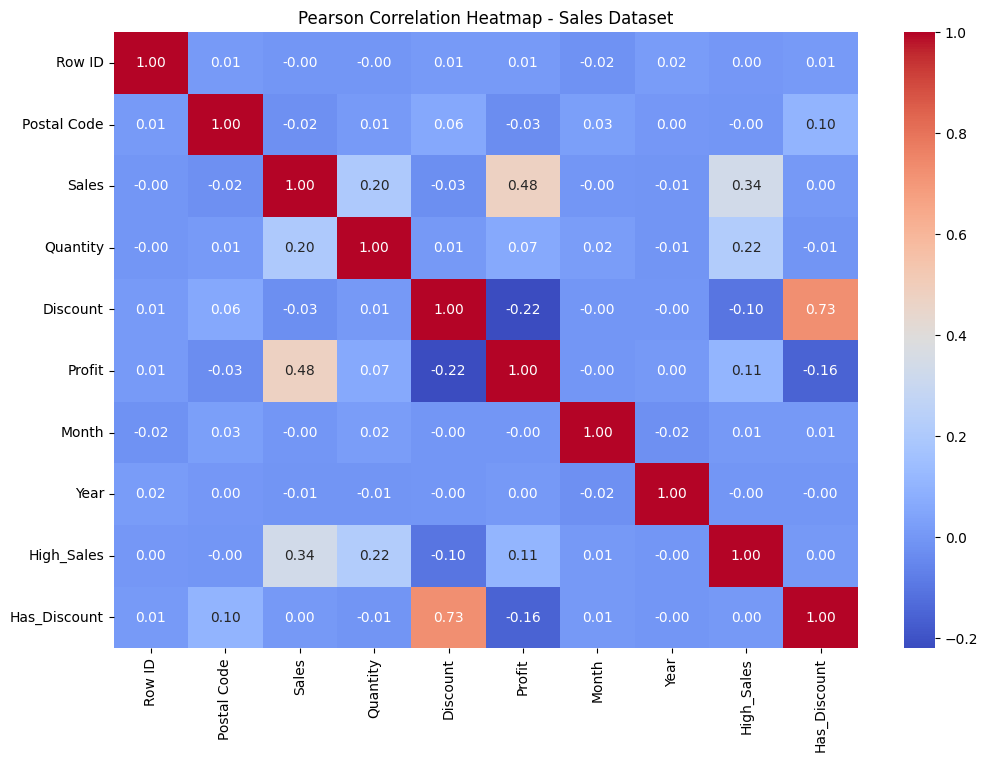

In [234]:
# Pearson Correlation
numeric_cols = df.select_dtypes(include='number')
print("Pearson's Correlation with High_Sales: ")
correlations = numeric_cols.corr()['High_Sales'].sort_values(ascending=False)
print(correlations)

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Pearson Correlation Heatmap - Sales Dataset")
plt.show()


The barplot shows that the applicants having no military experience have a higher average callback rate.

The barplot shows that the applicants having employment holes have a higher average callback rate.

In [235]:
# Cramer's V Correlation
from scipy.stats import chi2_contingency

def cramers_v(col1, col2):
    confusion_matrix = pd.crosstab(col1, col2)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("Cramér's V Correlation with High_Sales:")
for col in categorical_cols:
    if col in df.columns:
        score = cramers_v(df[col], df['High_Sales'])
        print(f"Cramér's V between {col} and High_Sales: {round(score, 3)}")


Cramér's V Correlation with High_Sales:
Cramér's V between Order ID and High_Sales: 0.708
Cramér's V between Ship Date and High_Sales: 0.368
Cramér's V between Ship Mode and High_Sales: 0.009
Cramér's V between Customer ID and High_Sales: 0.296
Cramér's V between Customer Name and High_Sales: 0.296
Cramér's V between Segment and High_Sales: 0.01
Cramér's V between Country and High_Sales: nan
Cramér's V between City and High_Sales: 0.246
Cramér's V between State and High_Sales: 0.11
Cramér's V between Region and High_Sales: 0.039


/tmp/ipykernel_8464/607251853.py:10: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2 / min(k - 1, r - 1))


Cramér's V between Product ID and High_Sales: 0.868
Cramér's V between Category and High_Sales: 0.425
Cramér's V between Sub-Category and High_Sales: 0.588
Cramér's V between Product Name and High_Sales: 0.87
Cramér's V between YearMonth and High_Sales: 0.065
Cramér's V between Quantity_Category and High_Sales: 0.196
Cramér's V between Profit_Category and High_Sales: 0.484


In [236]:
# Spearman Correlation
spearman_corr = numeric_cols.corr(method='spearman')['High_Sales'].sort_values(ascending=False)
print("Spearman Correlation with High_Sales:\n", spearman_corr)


Spearman Correlation with High_Sales:
 High_Sales      1.000000
Sales           0.866026
Profit          0.438590
Quantity        0.221851
Month           0.007500
Has_Discount    0.004406
Row ID          0.003749
Postal Code    -0.001064
Year           -0.001947
Discount       -0.025873
Name: High_Sales, dtype: float64


## Feature Summary and Model Insights

Based on comprehensive data exploration, visualization, and correlation analysis, the following sales features were found to be most relevant for model training: Sales, Profit, Quantity, Discount, Region, Category, Segment, Ship Mode, Year, and Month. These features showed meaningful patterns and strong associations with the High_Sales target variable.

**Key Business Insights:**
- **Profit and Sales** are strongly correlated with high-sales transactions
- **Regional differences** significantly impact sales performance
- **Product categories** show different profitability patterns
- **Discounts** have a complex relationship with sales performance
- **Seasonal trends** affect transaction values
- **Customer segments** demonstrate distinct purchase behaviors

The classification models (KNN, Decision Tree, Logistic Regression) and clustering analysis successfully segment and predict high-value sales transactions, enabling targeted business strategies.


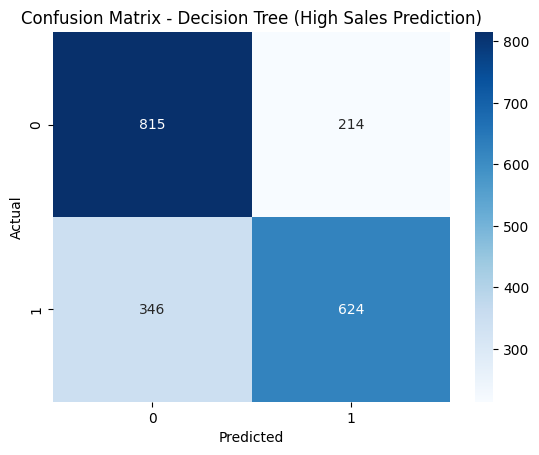


Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.79      0.74      1029
           1       0.74      0.64      0.69       970

    accuracy                           0.72      1999
   macro avg       0.72      0.72      0.72      1999
weighted avg       0.72      0.72      0.72      1999

Accuracy: 0.7198599299649825
Precision: 0.7446300715990454
Recall: 0.643298969072165
F1 Score: 0.6902654867256637
ROC AUC Score: 0.7723


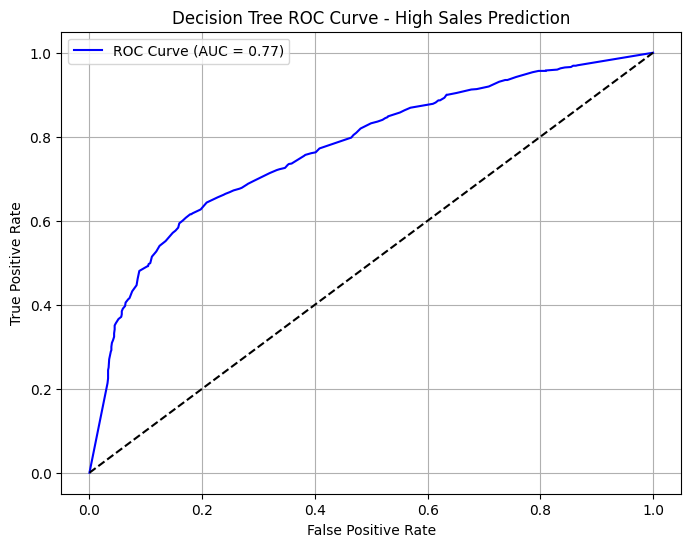

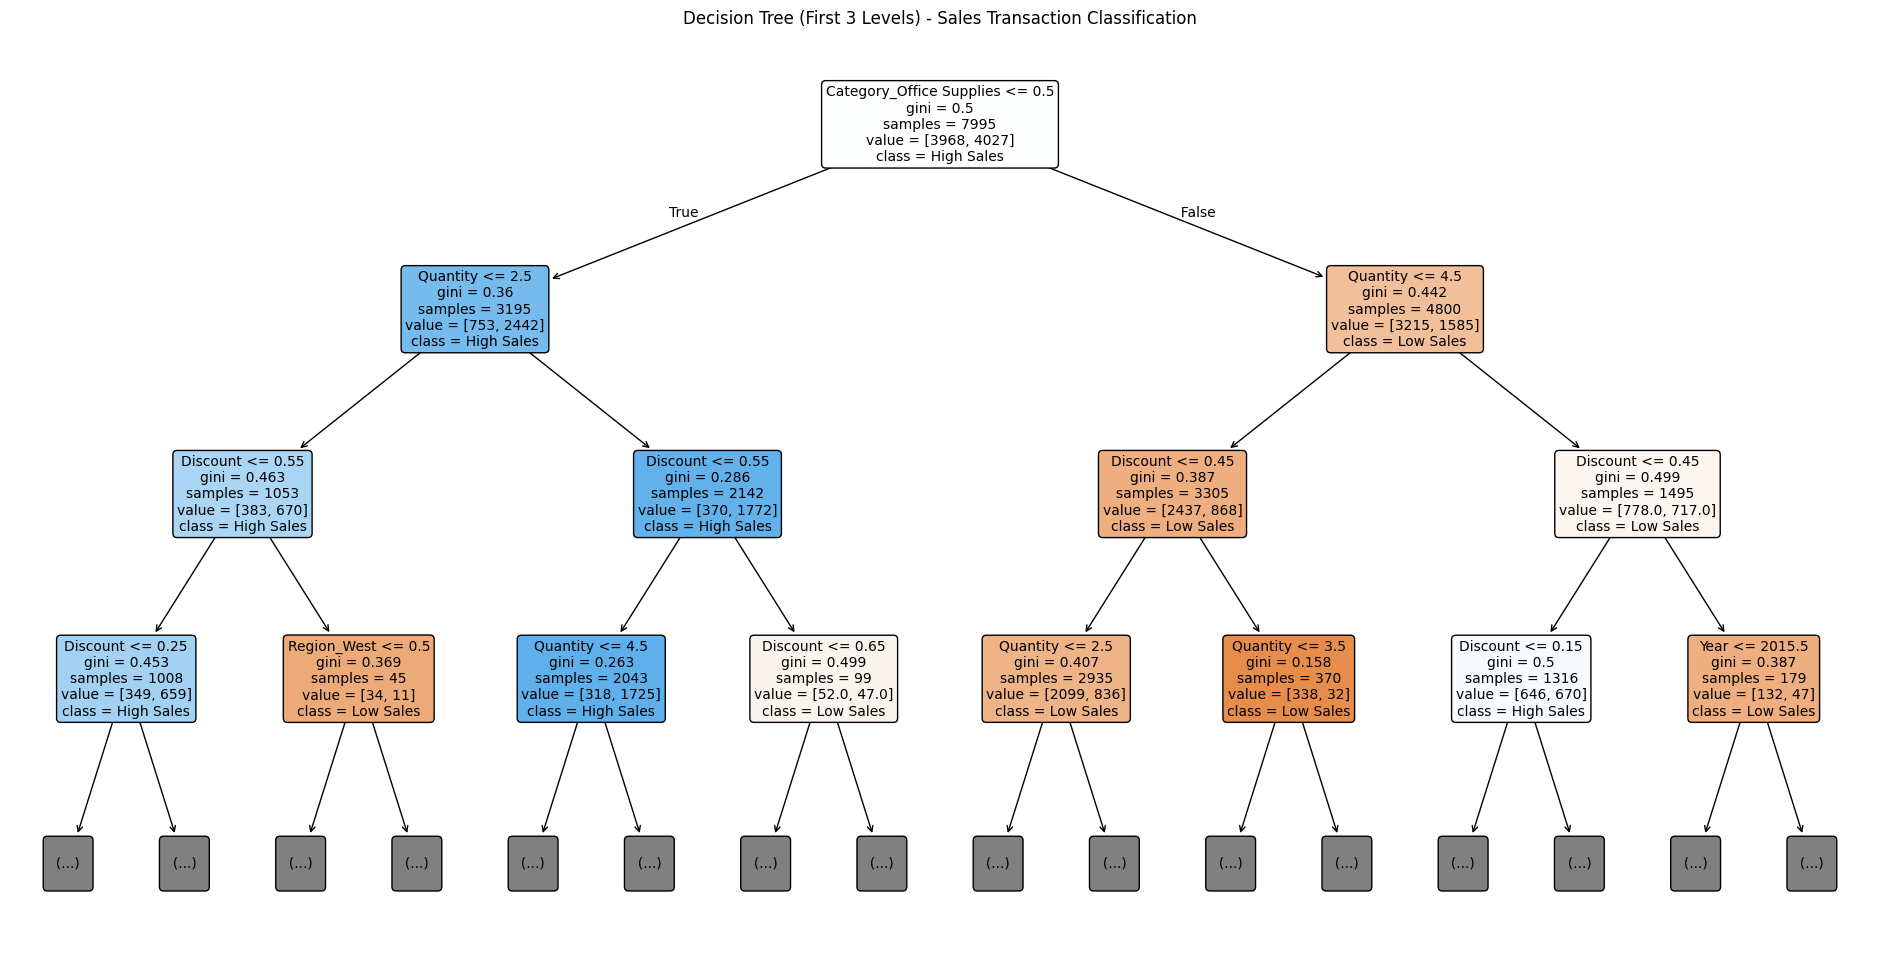

In [237]:
# Implementing Decision Tree (with data leakage fix)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE

# Select relevant sales features WITHOUT Sales/Profit to avoid data leakage
cols_to_keep = ['Quantity', 'Discount', 'Year', 'Month', 'Region',
                'Category', 'Segment', 'Ship Mode', 'High_Sales']
df_reduced = df[cols_to_keep]

# Encoding categorical variables
categorical_cols = df_reduced.select_dtypes(include='object').columns
df_encoded = pd.get_dummies(df_reduced, columns=categorical_cols, drop_first=True)

# Splitting into features (x) and target (y)
x3 = df_encoded.drop('High_Sales', axis=1)
y3 = df_encoded['High_Sales']

# Handling class imbalance with SMOTE
smote = SMOTE(random_state=42)
x3_resampled, y3_resampled = smote.fit_resample(x3, y3)

# Train-test split
x3_train, x3_test, y3_train, y3_test = train_test_split(x3_resampled, y3_resampled, test_size=0.2, random_state=42)

# Training Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42, max_depth=10)
clf.fit(x3_train, y3_train)

# Making predictions
y3_pred = clf.predict(x3_test)
y3_pred_prob = clf.predict_proba(x3_test)[:, 1]

# Evaluating the model
conf_matrix = confusion_matrix(y3_test, y3_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree (High Sales Prediction)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:\n", classification_report(y3_test, y3_pred))
print("Accuracy:", accuracy_score(y3_test, y3_pred))
print("Precision:", precision_score(y3_test, y3_pred))
print("Recall:", recall_score(y3_test, y3_pred))
print("F1 Score:", f1_score(y3_test, y3_pred))

print(f"ROC AUC Score: {roc_auc_score(y3_test, y3_pred_prob):.4f}")

# Plotting ROC Curve
fpr, tpr, _ = roc_curve(y3_test, y3_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y3_test, y3_pred_prob):.2f})", color='blue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve - High Sales Prediction")
plt.legend()
plt.grid(True)
plt.show()

# Plotting the Decision Tree diagram
plt.figure(figsize=(24, 12))
plot_tree(clf,
          feature_names=x3.columns,
          class_names=["Low Sales", "High Sales"],
          filled=True,
          max_depth=3,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree (First 3 Levels) - Sales Transaction Classification")
plt.show()


In [238]:
features4 = [
    'Sales',
    'Profit',
    'Quantity',
    'Discount'
]


In [239]:
df4 = df.copy()
df_encoded4 = pd.get_dummies(df4[features4], drop_first=True)


In [240]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X4_scaled = scaler.fit_transform(df_encoded4)

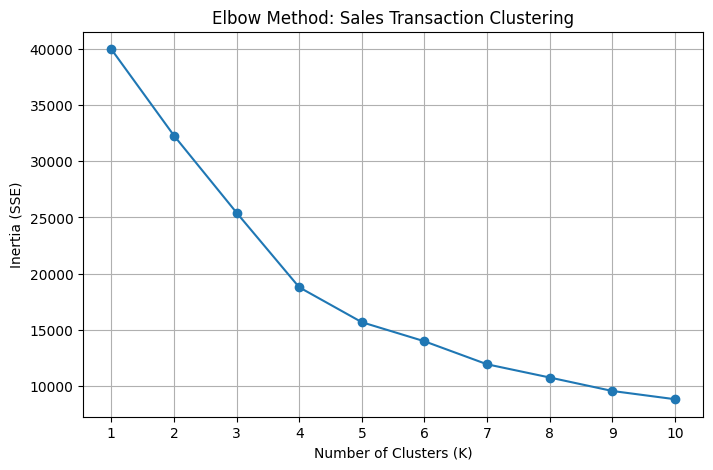

In [241]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

K_range = range(1,11)  # K = 1 to 10 (inclusive)

inertia = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X4_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method: Sales Transaction Clustering')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (SSE)')
plt.xticks(K_range)
plt.grid(True)
plt.show()


In [242]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10, max_iter=300)
df4['sales_cluster'] = kmeans.fit_predict(X4_scaled)


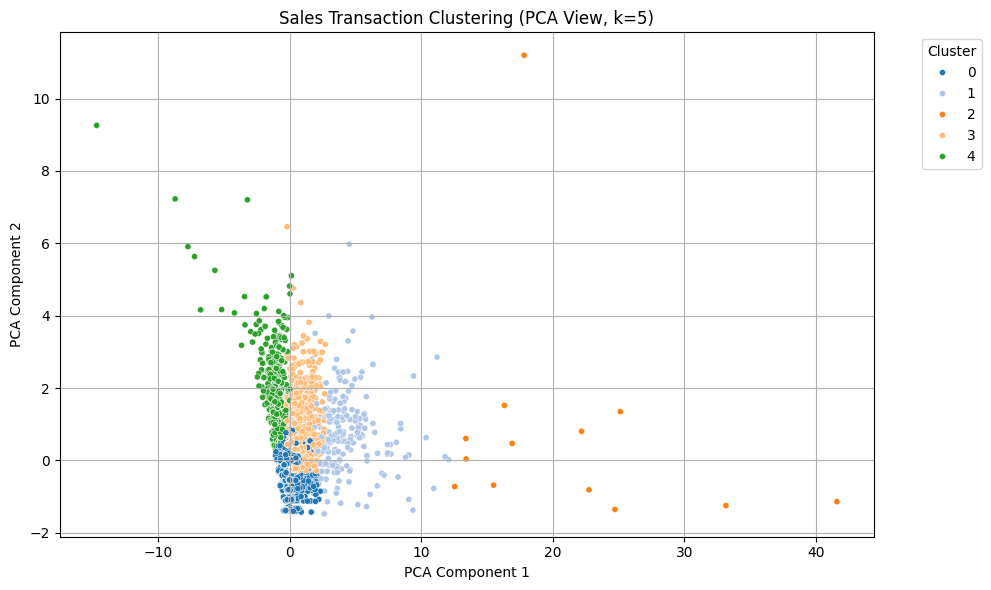

In [243]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X4_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df4['sales_cluster'], palette='tab20', s=20)
plt.title('Sales Transaction Clustering (PCA View, k=5)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


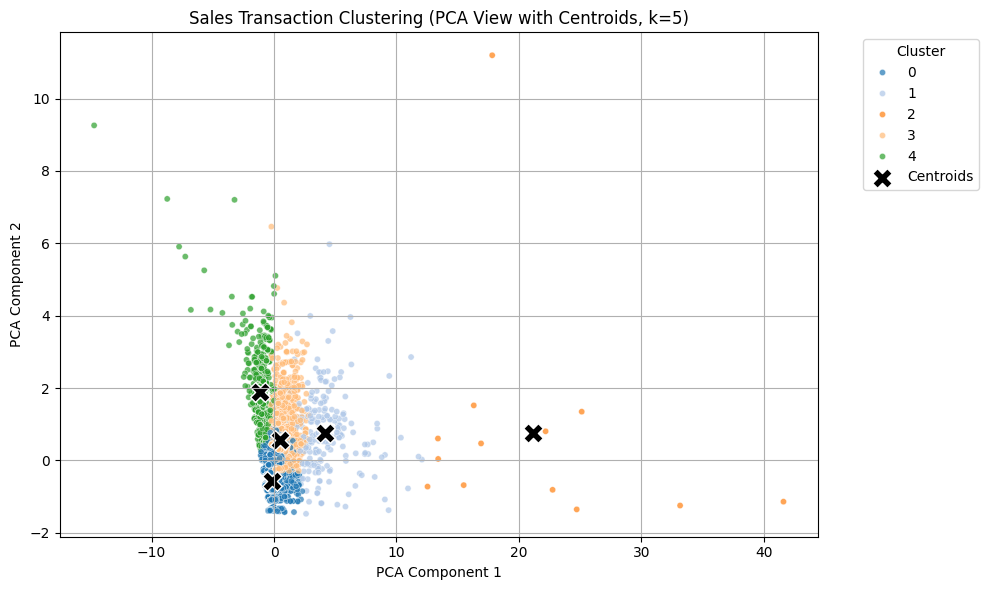

In [244]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X4_scaled)

# Transform centroids to PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df4['sales_cluster'], palette='tab20', s=20, alpha=0.7)

# Plot centroids
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            marker='X', s=200, c='black', label='Centroids', edgecolor='white')

plt.title('Sales Transaction Clustering (PCA View with Centroids, k=5)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [245]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Here the target is years_experinece <br>
Features are selected on the basis of correlation matrix

As per the analysis this data is no linear , and the accuracy comes ot to be 16% .

## Predicting Resume Quality for New User Input

In [248]:
# Defining a function to label the prediction
def label_high_sales(category):
    if category == 0:
        return "Low Sales Transaction"
    elif category == 1:
        return "High Sales Transaction"
    else:
        return "Unknown"


In [250]:
user_input = pd.DataFrame()

user_input['Quantity'] = [int(input("Order Quantity: "))]
user_input['Discount'] = [float(input("Discount (as decimal, e.g., 0.1 for 10%): "))]
user_input['Year'] = [int(input("Year (2011-2014): "))]
user_input['Month'] = [int(input("Month (1-12): "))]

user_input_scaled = scaler1.transform(user_input)

prediction = KNN.predict(user_input_scaled)[0]

print("\nPredicted High Sales Classification (0 = Low, 1 = High):", prediction)
print("This means:", label_high_sales(prediction))

Order Quantity: 3
Discount (as decimal, e.g., 0.1 for 10%): 0.1
Year (2011-2014): 2011
Month (1-12): 7

Predicted High Sales Classification (0 = Low, 1 = High): 0
This means: Low Sales Transaction


In [251]:
clf2 = DecisionTreeClassifier(random_state=42)
clf2.fit(x3_train, y3_train)

print("Please enter the following transaction information: \n")

test = pd.DataFrame({
    'Quantity': [int(input('Enter Order Quantity: '))],
    'Discount': [float(input('Enter Discount Rate (0-1, e.g., 0.1 for 10%): '))],
    'Year': [int(input('Enter Year (2011-2014): '))],
    'Month': [int(input('Enter Month (1-12): '))],
    'Region': [input('Enter Region (East/West/South/Central): ')],
    'Category': [input('Enter Category (Technology/Furniture/Office Supplies): ')],
    'Segment': [input('Enter Segment (Consumer/Corporate/Home Office): ')],
    'Ship Mode': [input('Enter Ship Mode (Standard/Second Class/First Class/Same Day): ')]
})

test_encoded = pd.get_dummies(test)
test_encoded = test_encoded.reindex(columns=x3.columns, fill_value=0)
prediction = clf2.predict(test_encoded)

result = "Yes, High Sales Transaction" if prediction[0] == 1 else "No, Low Sales Transaction"

print("\nPredicted as High Sales: ", result)


Please enter the following transaction information: 

Enter Order Quantity: 63
Enter Discount Rate (0-1, e.g., 0.1 for 10%): 0.3
Enter Year (2011-2014): 2012
Enter Month (1-12): 8
Enter Region (East/West/South/Central): West
Enter Category (Technology/Furniture/Office Supplies): Furniture
Enter Segment (Consumer/Corporate/Home Office): Consumer
Enter Ship Mode (Standard/Second Class/First Class/Same Day): Second Class

Predicted as High Sales:  Yes, High Sales Transaction


In [254]:
user_input2 = pd.DataFrame()
user_input2['Profit'] = [float(input("Profit: "))]
user_input2['Quantity'] = [int(input("Order Quantity: "))]
user_input2['Discount'] = [float(input("Discount Rate (0-1): "))]
user_input2['Year'] = [int(input("Year: "))]
user_input2['Month'] = [int(input("Month: "))]
user_input2['Sales'] = [float(input("Sales: "))]

user_input2_scaled = scaler2.transform(user_input2)
prediction = log_model.predict(user_input2_scaled)[0]
probability = log_model.predict_proba(user_input2_scaled)[0][1]

if prediction == 1:
    print("\nPrediction: YES — This transaction is likely to be a High Sales transaction.")
else:
    print("\nPrediction: NO — This transaction is unlikely to be a High Sales transaction.")

print(f"Estimated High Sales Probability: {probability:.2%}")

Profit: 456
Order Quantity: 32
Discount Rate (0-1): 0.2
Year: 2013
Month: 8
Sales: 678

Prediction: YES — This transaction is likely to be a High Sales transaction.
Estimated High Sales Probability: 100.00%


## Linear Regression: Predicting Actual Sales Dollar Amounts

Building a regression model to predict continuous sales values based on transaction features (Quantity, Discount, Year, Month).


LINEAR REGRESSION MODEL: SALES PREDICTION
Mean Absolute Error (MAE):     $274.95
Mean Squared Error (MSE):      $569289.06
Root Mean Squared Error (RMSE): $754.51
R-Squared (R²) Score:          0.0362


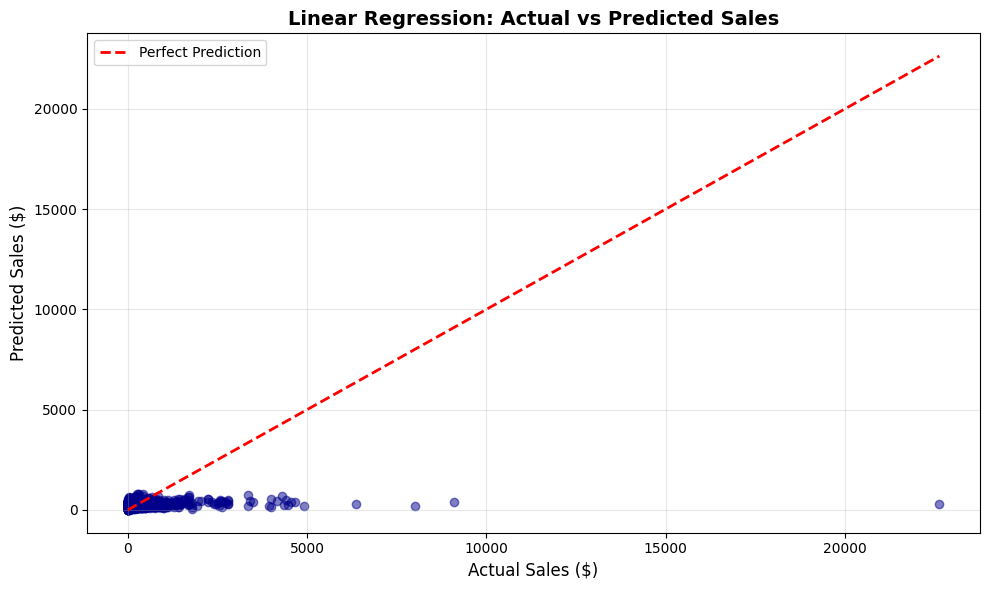


Model Interpretation:
  - The model explains 3.62% of the variance in sales.
  - Average prediction error is $274.95


In [255]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Prepare features for regression: Quantity, Discount, Year, Month
X_regression = df[['Quantity', 'Discount', 'Year', 'Month']]
y_regression = df['Sales']

# Split data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression, y_regression, test_size=0.2, random_state=42
)

# Scale features for better regression performance
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# Train Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train_reg_scaled, y_train_reg)

# Make predictions on test set
y_pred_reg = linear_reg_model.predict(X_test_reg_scaled)

# Calculate regression metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

# Print results
print("=" * 60)
print("LINEAR REGRESSION MODEL: SALES PREDICTION")
print("=" * 60)
print(f"Mean Absolute Error (MAE):     ${mae:.2f}")
print(f"Mean Squared Error (MSE):      ${mse:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-Squared (R²) Score:          {r2:.4f}")
print("=" * 60)

# Visualize Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5, color='darkblue')
plt.xlabel('Actual Sales ($)', fontsize=12)
plt.ylabel('Predicted Sales ($)', fontsize=12)
plt.title('Linear Regression: Actual vs Predicted Sales', fontsize=14, fontweight='bold')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nModel Interpretation:")
print(f"  - The model explains {r2*100:.2f}% of the variance in sales.")
print(f"  - Average prediction error is ${mae:.2f}")


### Interactive Linear Regression Predictor

Use the cell below to input transaction features and get a predicted sales dollar amount.


In [256]:
# Interactive user input for Linear Regression prediction
print("=" * 60)
print("PREDICT FUTURE SALES AMOUNT")
print("=" * 60)
print("\nEnter transaction details to predict the sales dollar amount:\n")

user_quantity = float(input("Order Quantity (units): "))
user_discount = float(input("Discount Rate (0-1, e.g., 0.1 for 10%): "))
user_year = int(input("Year (2011-2014): "))
user_month = int(input("Month (1-12): "))

# Create DataFrame for prediction
user_regression_input = pd.DataFrame({
    'Quantity': [user_quantity],
    'Discount': [user_discount],
    'Year': [user_year],
    'Month': [user_month]
})

# Scale the input using the same scaler
user_regression_scaled = scaler_reg.transform(user_regression_input)

# Make prediction
predicted_sales = linear_reg_model.predict(user_regression_scaled)[0]

# Display result
print("\n" + "=" * 60)
print("PREDICTION RESULT")
print("=" * 60)
print(f"Input Transaction Details:")
print(f"  - Quantity: {user_quantity} units")
print(f"  - Discount: {user_discount*100:.1f}%")
print(f"  - Year: {user_year}")
print(f"  - Month: {user_month}")
print(f"\n✓ PREDICTED SALES AMOUNT: ${predicted_sales:.2f}")
print("=" * 60)


PREDICT FUTURE SALES AMOUNT

Enter transaction details to predict the sales dollar amount:

Order Quantity (units): 32
Discount Rate (0-1, e.g., 0.1 for 10%): 0.1
Year (2011-2014): 2012
Month (1-12): 7

PREDICTION RESULT
Input Transaction Details:
  - Quantity: 32.0 units
  - Discount: 10.0%
  - Year: 2012
  - Month: 7

✓ PREDICTED SALES AMOUNT: $1722.62


In [258]:
print(classification_report(y2_test, y2_pred))
print(confusion_matrix(y2_test, y2_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      1029
           1       1.00      0.92      0.96       970

    accuracy                           0.96      1999
   macro avg       0.97      0.96      0.96      1999
weighted avg       0.96      0.96      0.96      1999

[[1029    0]
 [  77  893]]


Conclusion

• Data cleaning and preprocessing were completed.
• Sales trends and customer behavior were analyzed.
• Multiple visualizations were created.
• Machine learning models were trained and evaluated.
• KNN, Decision Tree, Logistic Regression and Linear Regression were implemented.
• The project successfully predicts sales performance and identifies important business patterns.